# Exploratory Data Analysis (EDA)

**Survivorship Bias - Selection Bias - Univariate Analysis - Multivariate Analysis - Correlation Structure**

---

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that should help this research to understand the underlying data better. Crucial concepts like Survivorship Bias, Outliers and Data Distribution will be explored in this notebook. To be precise, the following structure will be followed:

### **This notebook is structured as follows**

<table width="100%" style="border:none; border-collapse:separate; border-spacing:0 18px; table-layout:fixed;">
<tr>
<td width="33.3%" style="border:none; padding:0 10px 0 0; vertical-align:top;">

<div style="font-weight:700; font-size:1.0em; border-bottom:2px solid #8a94a6; padding-bottom:4px; margin-bottom:7px;">0. Loading Data &amp; Libraries</div>
<div style="font-size:0.85em; opacity:0.78; line-height:1.45; margin-bottom:8px; min-height:1.2em;"><!-- Description --></div>
</td>
<td width="33.3%" style="border:none; padding:0 10px 0 0; vertical-align:top;">

<div style="font-weight:700; font-size:1.0em; border-bottom:2px solid #8a94a6; padding-bottom:4px; margin-bottom:7px;">1. Selection &amp; Survivorship Bias</div>
<div style="font-size:0.85em; opacity:0.78; line-height:1.45; margin-bottom:8px; min-height:1.2em;"><!-- Description --></div>
<div style="font-size:0.9em; line-height:1.65;">
<b>1.1.</b> Survivorship Bias: Overview<br>
<b>1.2.</b> Market Capitalization<br>
<b>1.3.</b> Valuation Ratios<br>
<b>1.4.</b> Firm Life Cycle<br>
</div>
</td>
<td width="33.3%" style="border:none; padding:0 10px 0 0; vertical-align:top;">

<div style="font-weight:700; font-size:1.0em; border-bottom:2px solid #8a94a6; padding-bottom:4px; margin-bottom:7px;">2. Univariate Data Analysis</div>
<div style="font-size:0.85em; opacity:0.78; line-height:1.45; margin-bottom:8px; min-height:1.2em;"><!-- Description --></div>
<div style="font-size:0.9em; line-height:1.65;">
<b>2.1.</b> Distribution of the Target Variables<br>
<b>2.2.</b> Valuation Ratios<br>
<b>2.3.</b> Market Ratios<br>
<b>2.4.</b> Profitability Ratios<br>
<b>2.5.</b> Horizon Window<br>
</div>
</td>
</tr>
<tr>
<td style="border:none; padding:0 10px 0 0; vertical-align:top;">

<div style="font-weight:700; font-size:1.0em; border-bottom:2px solid #8a94a6; padding-bottom:4px; margin-bottom:7px;">3. Bivariate Data Analysis</div>
<div style="font-size:0.85em; opacity:0.78; line-height:1.45; margin-bottom:8px; min-height:1.2em;"><!-- Description --></div>
<div style="font-size:0.9em; line-height:1.65;">
<b>3.1.</b> Correlation Analysis<br>
<b>3.2.</b> Distribution of Growth Rate by Important Categories<br>
<b>3.3.</b> Further Bivariate Distributions<br>
<b>3.4.</b> Mean-Reversion of Growth<br>
<b>3.5.</b> Time-Varying Data Analysis<br>
</div>
</td>
<td style="border:none; padding:0 10px 0 0; vertical-align:top;">

<div style="font-weight:700; font-size:1.0em; border-bottom:2px solid #8a94a6; padding-bottom:4px; margin-bottom:7px;">4. Multivariate Data Analysis</div>
<div style="font-size:0.85em; opacity:0.78; line-height:1.45; margin-bottom:8px; min-height:1.2em;"><!-- Description --></div>
<div style="font-size:0.9em; line-height:1.65;">
<b>4.1.</b> Mean-Reversion Depending on Time, Lifecycle Stage and Profitability<br>
<b>4.2.</b> Target Variable by Sector for above-average vs below-average profitability margin<br>
<b>4.3.</b> Principal Component Analysis (PCA)<br>
</div>
</td>
<td style="border:none; padding:0 10px 0 0; vertical-align:top;">

<div style="font-weight:700; font-size:1.0em; border-bottom:2px solid #8a94a6; padding-bottom:4px; margin-bottom:7px;">5. EDA Storage</div>
<div style="font-size:0.85em; opacity:0.78; line-height:1.45; margin-bottom:8px; min-height:1.2em;"><!-- Description --></div>
<div style="font-size:0.9em; line-height:1.65;">
<b>5.1.</b> Outlier Handling<br>
</div>
</td>
</tr>
</table>

---

## **0. Loading Data & Libraries**

In the first part the necessary libraries will be loaded, as well as the cleaned data from the Data Preparation notebook.

In [159]:
#Load the necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [160]:
#Load the datasets
df_a = pd.read_csv('/Users/jannemeth/Desktop/HSG/Semester 6 /Capstone/Bachelor_Thesis/Data/final_dataset.csv')
df_1 = pd.read_csv('/Users/jannemeth/Desktop/HSG/Semester 6 /Capstone/Bachelor_Thesis/Data/final_dataset_2.csv')
df_2 = pd.read_csv('/Users/jannemeth/Desktop/HSG/Semester 6 /Capstone/Bachelor_Thesis/Data/final_dataset_3.csv')

#For comparison we will also load the crsp and compustat data directly before data filtering.
#Only the columns actually used are read 
compustat = pd.read_csv(
    '/Users/jannemeth/Desktop/HSG/Semester 6 /Capstone/Bachelor_Thesis/Data/compustat_funda_new4.csv',
    usecols=['gvkey', 'fyear', 'datadate', 'conm', 'costat', 'gsector',
             'prcc_f', 'csho', 'ceq', 'at', 'ib'])

crsp = pd.read_csv('/Users/jannemeth/Desktop/HSG/Semester 6 /Capstone/Bachelor_Thesis/Data/crsp_merged.csv', usecols=['beta'])

---

## **1. Selection & Survivorship Bias**

The first major section deals with the concepts of Selection and Survivorship Bias. **Selection Bias** refers to the fact that the data used in this research is not a random sample of all possible US-listed companies, but more a specific subset of companies that withstand the filtering process, e.g. only companies with non-missing data are included in the dataset, which could be a reason for selection bias (maybe larger companies have more data available). The issue of **Survivorship Bias** arises naturally from the specific prediction task. This is because this thesis aims to predict the long term growth rates of companies in t+5 to t+10 years, and the crucial condition to do so is survival of the underlying companies in this time frame.

Both concepts will be explored in this section, and the potential impact on the research will be further discussed in the thesis.

### 1.1. Survivorship Bias: Overview

**Raw Survivorship Bias**

First of all, let's see how many observations were lost from the Raw Compustat Fundamental Set to the final cleaned dataset with target variables available.

In [161]:
#Look at the number of available data points in the raw and cleaned datasets 
length_cleaned = len(df_1[(df_1['ebitda_cagr'].notna()) | (df_1['ebitda_lsq'].notna()) | (df_1['fcff_cagr'].notna()) | (df_1['fcff_lsq'].notna()) | (df_1['sale_cagr'].notna()) | (df_1['sale_lsq'].notna())])
length_raw = len(compustat)

print(f"Raw data points: {length_raw}")
print(f"Cleaned data points: {length_cleaned}")
print(f"Data loss: {length_raw - length_cleaned}")
print(f"Data loss percentage: {round((length_raw - length_cleaned) / length_raw * 100, 2)}%")

Raw data points: 345288
Cleaned data points: 60120
Data loss: 285168
Data loss percentage: 82.59%


One can see that the data loss is significant, more than 285.168 meaning over 82% of initial data points have been lost due to filtering and cleaning that was necessary to ensure the quality of the dataset. To see how many companies were lost due to the survivorship conditions in the target variable (explicit Survivorship Bias), the next step looks at the number of firms that have been removed from the dataset, as well as the composition of active and inactive firms due to missing data in the target variable on the larger dataset with analyst coverage.

(Starting from the next section with Market Capitalization, the number of firms that have been removed from the dataset due to missing data in the target variable is examined on both datasets, with and without analyst coverage, and the two are compared additionally)

In [162]:
#Look at the Share of Active Firms in the Dataset with and without survivorship bias
print(f' Dataset with Target Variable available: {round(df_1[df_1["ebitda_cagr"].notna()]["costat"].value_counts() / len(df_1[df_1["ebitda_cagr"].notna()]["costat"]) * 100, 2)}')
print(f' Dataset with Target Variable not available: {round(df_1[~df_1["ebitda_cagr"].notna()]["costat"].value_counts() / len(df_1[~df_1["ebitda_cagr"].notna()]["costat"]) * 100, 2)}')

print(f' Full Dataset (Cleaned): {round(df_1["costat"].value_counts() / len(df_1["costat"]) * 100, 2)}')
print(f' Compustat Fundamental Set: {round(compustat["costat"].value_counts() / len(compustat["costat"]) * 100, 2)}')

 Dataset with Target Variable available: costat
A    57.34
I    42.66
Name: count, dtype: float64
 Dataset with Target Variable not available: costat
I    69.84
A    30.16
Name: count, dtype: float64
 Full Dataset (Cleaned): costat
I    59.67
A    40.33
Name: count, dtype: float64
 Compustat Fundamental Set: costat
I    57.67
A    42.33
Name: count, dtype: float64


The number of active and inactive firms in the dataset with and without survivorship bias is shown above. It can be seen that the share of active firms in the dataset with target variable available is 57.34% while the share of active firms in the full dataset is 40.33% and in the Compustat Fundamental Set it is 42.33%. Regarding survivorship bias, in the dataset where the target variable is missing the share of active firms is only 30.16%, being almost half of the share of active firms in the dataset with target variable available. This indicates that there is a significant amount of survivorship bias in the used dataset towards active firms.

The next table looks at the median of the numeric features in the filtered dataset with and without survivorship bias. 

In [163]:
#Summarization Table of Survivorship Bias for the Numeric Features

df_1['has_target'] = df_1['ebitda_cagr'].notna()

cols = ['mkvalt_adj','ROA','op_margin','beta','idio_vol','D-A','B-M','S-P']
tab = df_1.groupby('has_target')[cols].median().T 
tab.columns = ['No target','Valid target']
tab['Ratio'] = (tab['Valid target']/tab['No target']).round(2)
tab.round(2)

,No target,Valid target,Ratio
mkvalt_adj,146.36,570.32,3.90
ROA,0.26,4.66,18.19
op_margin,6.76,13.14,1.94
beta,1.16,1.01,0.87
idio_vol,0.53,0.36,0.67
D-A,19.78,22.75,1.15
B-M,0.45,0.47,1.04
S-P,0.80,1.04,1.29


In [164]:
#Look at size differences between the datasets with and without target variable available
print(df_1.groupby('has_target').size())

has_target
False    76550
True     45794
dtype: int64


One can see, especially for the ROA as well as the Market Capitalization, that the median of the numeric features is significantly higher in the dataset with the target variable available, imposing a significant survivorship bias. This is especially important to consider for the analysis, as it can lead to biased results. The next section looks at the detailed breakdown of survivorship but also selection bias in crucial dataset columns.

### 1.2. Market Capitalization

One of the main variables of interest to look at Survivorship Bias will be the market capitalization of the companies, which follows a clear economic reasoning: larger companies have a higher probability to survive the cleaning process, since they have a higher analyst coverage and are better tracked by Compustat etc. I will first explore the Market Cap with and without Analyst Coverage and compare both to the unfiltered Compustat dataset to get a sense of the Selection Bias in the data.

In [165]:
print(f' Dataset with Analyst Coverage: {round(df_a["mkvalt_adj"].describe(), 2)}')
print(f' Dataset without Analyst Coverage: {round(df_1["mkvalt_adj"].describe(), 2)}')


#Compustat Comparison:
compustat['mkvalt_adj'] = compustat['prcc_f'] * compustat['csho']
print(f' Compustat Dataset: {round(compustat["mkvalt_adj"].describe(), 2)}')


 Dataset with Analyst Coverage: count      57211.00
mean        7533.93
std        55246.67
min            0.89
25%          173.13
50%          680.50
75%         2940.95
max      3761715.19
Name: mkvalt_adj, dtype: float64
 Dataset without Analyst Coverage: count     122344.00
mean        4605.08
std        42903.52
min            0.06
25%           46.23
50%          243.79
75%         1344.84
max      3783544.00
Name: mkvalt_adj, dtype: float64
 Compustat Dataset: count     292300.00
mean        2881.65
std        30891.92
min            0.00
25%           25.20
50%          127.32
75%          699.74
max      4645223.52
Name: mkvalt_adj, dtype: float64


One can see a huge difference in the distribution of the Market Capitalization between the dataset with and without analyst coverage. The one with Analyst Coverage has a 3x higher median and higher mean Market Capitalization. The divergence becomes even more severe when looking at the Compustat Raw Dataset, making the Median roughly 5x higher and the Mean 3x higher compared to the dataset with Analyst Coverage. This shows that both datasets, even when accounting for analyst coverage, are still biased towards larger companies.

To explore the Survivorship Bias further, the next step looks at the data where companies have a not missing target variable (EBITDA will be used as the target variable). The distribution of the Market Capitalization is examined for companies with and without missing EBITDA (in the analyst covered dataset and the not analyst covered dataset).

In [166]:
print(f' Dataset with Analyst Coverage and no missing EBITDA Growth Rate: {round(df_a[df_a['ebitda_cagr'].notna()]['mkvalt_adj'].describe(), 2)}')
print(f' Dataset with Analyst Coverage: {round(df_a['mkvalt_adj'].describe(), 2)}')
print(f' Dataset without Analyst Coverage and no missing EBITDA Growth Rate: {round(df_1[df_1['ebitda_cagr'].notna()]['mkvalt_adj'].describe(), 2)}')
print(f' Dataset without Analyst Coverage: {round(df_1['mkvalt_adj'].describe(), 2)}')

 Dataset with Analyst Coverage and no missing EBITDA Growth Rate: count     27695.00
mean       7218.32
std       26387.09
min           1.22
25%         296.77
50%        1051.90
75%        3926.16
max      790050.10
Name: mkvalt_adj, dtype: float64
 Dataset with Analyst Coverage: count      57211.00
mean        7533.93
std        55246.67
min            0.89
25%          173.13
50%          680.50
75%         2940.95
max      3761715.19
Name: mkvalt_adj, dtype: float64
 Dataset without Analyst Coverage and no missing EBITDA Growth Rate: count     45794.00
mean       5293.73
std       23180.19
min           0.12
25%         105.46
50%         570.32
75%        2453.95
max      790050.10
Name: mkvalt_adj, dtype: float64
 Dataset without Analyst Coverage: count     122344.00
mean        4605.08
std        42903.52
min            0.06
25%           46.23
50%          243.79
75%         1344.84
max      3783544.00
Name: mkvalt_adj, dtype: float64


One can see that the target variable definition of required horizons (t+5 to t+10) again induces a set of survivorship bias in both datasets. In the dataset without Analyst Coverage the median roughly doubles, while for the dataset with Analyst Coverage the median is increasing by 40% as well. Concluding, Survivorship Bias is present in both datasets.

### 1.3. Valuation Ratios

Next up, the distribution of Valuation Multiples is examined, seeing if there is any Growth vs. Value bias in the datasets. The Book to Market (B/M) ratio is used as the classical convention for Growth vs Value comparison.

In [167]:
#Compare the B-M ratio between the datasets with and without analyst coverage and target variable available as well as the standard compustat dataset
print(f' Dataset with Analyst Coverage: {round(df_a['B-M'].describe(), 2)}')
print(f' Dataset without Analyst Coverage: {round(df_1['B-M'].describe(), 2)}')

print(f' Dataset with Analyst Coverage Target Variable not missing: {round(df_a[df_a['ebitda_cagr'].notna()]['B-M'].describe(), 2)}')
print(f' Dataset without Analyst Coverage Target Variable not missing: {round(df_1[df_1['ebitda_cagr'].notna()]['B-M'].describe(), 2)}')

compustat['B-M'] = compustat['ceq'] / compustat['mkvalt_adj']
print(f' Compustat Dataset: {round(compustat['B-M'].describe(), 2)}')


 Dataset with Analyst Coverage: count    57211.00
mean         0.51
std          1.05
min        -84.78
25%          0.24
50%          0.43
75%          0.69
max         52.83
Name: B-M, dtype: float64
 Dataset without Analyst Coverage: count    122344.00
mean          0.54
std           3.60
min        -906.64
25%           0.24
50%           0.46
75%           0.78
max         110.12
Name: B-M, dtype: float64
 Dataset with Analyst Coverage Target Variable not missing: count    27695.00
mean         0.49
std          1.01
min        -84.78
25%          0.26
50%          0.43
75%          0.66
max         29.35
Name: B-M, dtype: float64
 Dataset without Analyst Coverage Target Variable not missing: count    45794.00
mean         0.53
std          2.30
min       -311.90
25%          0.28
50%          0.47
75%          0.74
max         30.17
Name: B-M, dtype: float64
 Compustat Dataset: count    233343.00
mean           NaN
std            NaN
min           -inf
25%           0.20
50%    

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


At least in terms of Growth vs Value, there seems to be no significant difference between the two datasets. The dataset with Analyst Coverage has a slightly lower median and mean B/M ratio, but the difference is not substantial. Similarly, the not missing constraints on both datasets do not induce a significant difference in the B/M ratio. Even compared to the median of the Compustat dataset it is rather similar.

In [168]:
#Compare the S-P ratio between the datasets with and without analyst coverage
print(f' Dataset with Analyst Coverage: {round(df_a['S-P'].describe(), 2)}')
print(f' Dataset without Analyst Coverage: {round(df_1['S-P'].describe(), 2)}')

 Dataset with Analyst Coverage: count    57211.00
mean         1.77
std          4.42
min         -0.05
25%          0.40
50%          0.84
75%          1.75
max        270.80
Name: S-P, dtype: float64
 Dataset without Analyst Coverage: count    122344.00
mean          2.24
std           6.88
min          -0.19
25%           0.37
50%           0.90
75%           2.10
max         554.10
Name: S-P, dtype: float64


Again, also in the Sales to Market Cap there are only slight differences between the two datasets in terms of the median and mean.

Next up, the difference in market exposures (measured by beta) between the two datasets is examined, to see if one is more exposed to market changes than the other.

In [169]:
#Compare the beta between the datasets with and without analyst coverage, and with and without target variable available as well as the standard CRSP dataset
print(f' Dataset with Analyst Coverage: {round(df_a['beta'].describe(), 2)}')
print(f' Dataset without Analyst Coverage: {round(df_1['beta'].describe(), 2)}')

print(f' Dataset with Analyst Coverage Target Variable not missing: {round(df_a[df_a['ebitda_cagr'].notna()]['beta'].describe(), 2)}')
print(f' Dataset without Analyst Coverage Target Variable not missing: {round(df_1[df_1['ebitda_cagr'].notna()]['beta'].describe(), 2)}')

print(f' CRSP Data: {round(crsp['beta'].describe(), 2)}')



 Dataset with Analyst Coverage: count    57211.00
mean         1.25
std          0.82
min         -6.77
25%          0.73
50%          1.14
75%          1.61
max          8.54
Name: beta, dtype: float64
 Dataset without Analyst Coverage: count    122344.00
mean          1.19
std           0.90
min         -12.13
25%           0.65
50%           1.10
75%           1.61
max          38.70
Name: beta, dtype: float64
 Dataset with Analyst Coverage Target Variable not missing: count    27695.00
mean         1.14
std          0.73
min         -3.43
25%          0.67
50%          1.05
75%          1.46
max          7.58
Name: beta, dtype: float64
 Dataset without Analyst Coverage Target Variable not missing: count    45794.00
mean         1.09
std          0.75
min         -5.85
25%          0.61
50%          1.01
75%          1.44
max          7.58
Name: beta, dtype: float64
 CRSP Data: count    3023718.00
mean           1.00
std            0.89
min         -119.07
25%            0.48
50%   

In terms of the Median and Mean, both are similarly exposed to market changes, with slight upward tendencies for the dataset with Analyst Coverage. However, I can conclude that market exposure differences are not a highly critical factor in the difference between the two datasets. Similarly, there are no crucial differences in the observations where the target variables are not missing. Attention: compared to the standard CRSP datasets both datasets have slightly higher market exposures!

Next up, the distribution of the profitability between the datasets is examined. Since this is a crucial factor for the growth rate convergence, Operating Margin and Return on Assets (ROA) are used as the two profitability measures.

In [170]:
#Compare the ROA between the datasets with and without analyst coverage, and with and without target variable available 
print(f' Dataset with Analyst Coverage: {round(df_a['ROA'].describe(), 2)}')
print(f' Dataset without Analyst Coverage: {round(df_1['ROA'].describe(), 2)}')

print(f' Dataset with Analyst Coverage Target Variable not missing: {round(df_a[df_a['ebitda_cagr'].notna()]['ROA'].describe(), 2)}')
print(f' Dataset without Analyst Coverage Target Variable not missing: {round(df_1[df_1['ebitda_cagr'].notna()]['ROA'].describe(), 2)}')

#Has to be implented better: 
#compustat['ROA'] = compustat['ib'] / compustat['at'] * 100
# compustat['ROA'].dropna(inplace=True)
# print(f' Compustat Dataset: {round(compustat['ROA'].describe(), 2)}')


 Dataset with Analyst Coverage: count    57211.00
mean         0.13
std         23.77
min      -1153.33
25%          0.08
50%          4.16
75%          8.08
max        161.70
Name: ROA, dtype: float64
 Dataset without Analyst Coverage: count    122344.00
mean         -8.62
std          65.98
min      -10001.40
25%          -6.91
50%           2.55
75%           6.75
max         644.97
Name: ROA, dtype: float64
 Dataset with Analyst Coverage Target Variable not missing: count    27695.00
mean         4.65
std         12.32
min       -577.85
25%          2.31
50%          5.22
75%          9.03
max         72.24
Name: ROA, dtype: float64
 Dataset without Analyst Coverage Target Variable not missing: count    45794.00
mean         3.26
std         17.27
min      -1971.93
25%          1.50
50%          4.66
75%          8.44
max         82.16
Name: ROA, dtype: float64


One can see big differences in terms of profitability between the two datasets. With Analyst Coverage the Return on Assets Median is roughly 4.16% where it is 2.55% for the dataset without Analyst Coverage. Interestingly, when looking at the not missing target variable constraints, both datasets are more similar: 5.22% vs. 4.66% for the dataset with and without Analyst Coverage. This implies that a true survivorship bias sits in Profitability, making firms with lower profitability less likely to survive the target horizons. More drastically, this can also be seen in the Overview Table in Section 1.1., the profitability differences where the target variable is missing vs non-missing are extremely high.

### 1.4. Firm Life Cycle

In this section, Selection and Survivorship Bias implications are examined in terms of the firm life cycle characteristics further discussed in the thesis.

In [171]:
#Plot the distribution of Monthly Returns for the two datasets
print(f' Lifecycle Percentage with Analyst Coverage: {round(df_a['lifecycle'].value_counts() / len(df_a['lifecycle']) * 100, 2)}')
print(f' Lifecycle Percentage without Analyst Coverage: {round(df_1['lifecycle'].value_counts() / len(df_1['lifecycle']) * 100, 2)}')

print(f' Lifecycle Percentage with Analyst Coverage Target Variable not missing: {round(df_a[df_a['ebitda_cagr'].notna()]['lifecycle'].value_counts() / len(df_a[df_a['ebitda_cagr'].notna()]['lifecycle']) * 100, 2)}')
print(f' Lifecycle Percentage without Analyst Coverage Target Variable not missing: {round(df_1[df_1['ebitda_cagr'].notna()]['lifecycle'].value_counts() / len(df_1[df_1['ebitda_cagr'].notna()]['lifecycle']) * 100, 2)}')

#Has to be implented better: 
#compustat['ROA'] = compustat['ib'] / compustat['at'] * 100
# compustat['ROA'].dropna(inplace=True)
# print(f' Compustat Dataset: {round(compustat['ROA'].describe(), 2)}')


 Lifecycle Percentage with Analyst Coverage: lifecycle
Maturity        44.84
Growth          33.15
Introduction     9.57
Shake-out        7.93
Decline          4.51
Name: count, dtype: float64
 Lifecycle Percentage without Analyst Coverage: lifecycle
Maturity        39.27
Growth          26.86
Introduction    16.55
Shake-out        9.09
Decline          8.22
Name: count, dtype: float64
 Lifecycle Percentage with Analyst Coverage Target Variable not missing: lifecycle
Maturity        51.77
Growth          34.75
Shake-out        6.77
Introduction     5.01
Decline          1.70
Name: count, dtype: float64
 Lifecycle Percentage without Analyst Coverage Target Variable not missing: lifecycle
Maturity        50.29
Growth          32.13
Shake-out        7.98
Introduction     6.90
Decline          2.70
Name: count, dtype: float64


Regarding Selection Bias, one can see that the order of life cycle stages is exactly the same in the datasets with and without analyst coverage. However, the proportions are significantly different. Non surprisingly, the dataset with analyst coverage has a higher share of Maturity and Growth firms, while the dataset without analyst coverage relatively incorporates more firms in the Introduction phase. This is not only a sign for selection bias, but also potentially justifies the Cash Flow Patterns as a proxy for the firm life cycle stages, since the differences between the two datasets are exactly as expected from an economic perspective.

From a Survivorship Bias perspective the change in the dataset is drastic. There are almost no firms with target variables that are in a Decline or Introduction stage, but they are even more concentrated in Maturity and Growth Life Cycles. Therefore the later developed machine learning model will be potentially biased to cover Growth and Maturity firms way better than Introduction and Decline or Shakeout firms.

---

## **2. Univariate Data Analysis**

While covering explicit Survivorship and Selection Bias in key features in the last section, this section will explore univariate properties of the datasets. Starting with the target variable distributions and the comparison between the different target variables and calculation methods (CAGR vs LSQ), going over to studying specific feature sets (e.g. Valuation, Profitability, Market Ratios).

### 2.1. Distribution of the Target Variables

In this section the distribution of the target variables with and without analyst coverage is examined. But first of all I have to specify how outliers are treated in the target variable. For this I define the function 'wlog' which is a winsorized log transformation of a specific target variable.

Note: Even when more variables are under consideration, I understand looking at different target variables as univariate analysis (not multivariate), since they are not there to compare relations between variables, but to look at the distribution differences in the definition of the target variable.

In [172]:
#Initiaze a target variable list
y_list = ['ebitda_cagr', 'ebitda_lsq', 'sale_cagr', 'sale_lsq', 'fcff_cagr', 'fcff_lsq']


In [173]:
#Define a function to winsorize and log transform the target variables, that takes as input a pandas series (or a pandas dataframe) and returns the winsorized and log transformed values.
def wlog(x, q=0.01):
    
    """1%/99% winsorization per column in raw space, then log1p."""

    lo, hi = x.quantile(q), x.quantile(1 - q)
    #Handling if Series or Dataframe is passed as input
    x = x.clip(lo, hi, axis=1) if isinstance(x, pd.DataFrame) else x.clip(lo, hi)
    return np.log1p(x)

In a first step, the distributions of all the target variables (with CAGR calculations) in the dataset with and without analyst coverage are examined.

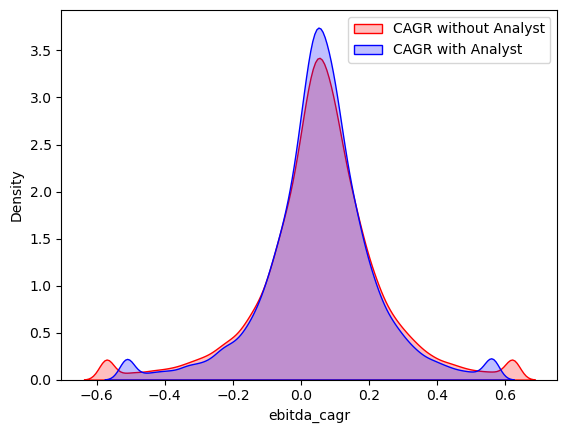

In [174]:
#Distribution of EBITDA CAGR with and without analyst coverage
sns.kdeplot(wlog(df_1['ebitda_cagr']), fill=True, color='r', label='CAGR without Analyst')
sns.kdeplot(wlog(df_a['ebitda_cagr']), fill=True, color='b', label='CAGR with Analyst')
plt.legend()
plt.show()

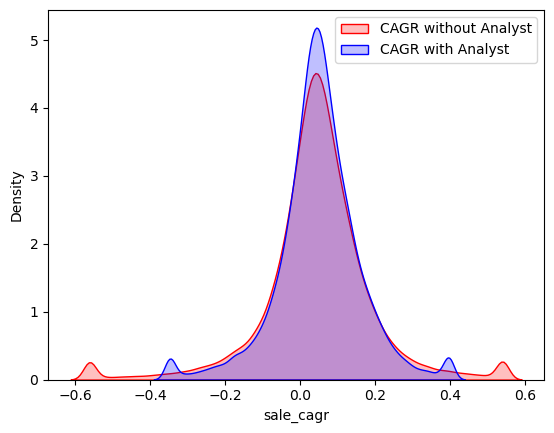

In [175]:
#Distribution of Sale CAGR with and without analyst coverage
sns.kdeplot(wlog(df_1['sale_cagr']), fill=True, color='r', label='CAGR without Analyst')
sns.kdeplot(wlog(df_a['sale_cagr']), fill=True, color='b', label='CAGR with Analyst')
plt.legend()
plt.show()

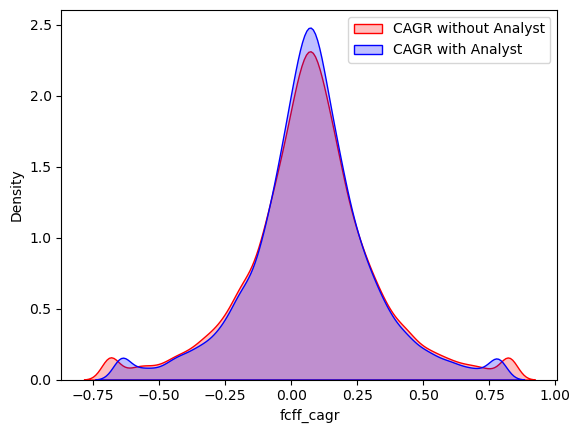

In [176]:
#Distribution of FCFF CAGR with and without analyst coverage
sns.kdeplot(wlog(df_1['fcff_cagr']), fill=True, color='r', label='CAGR without Analyst')
sns.kdeplot(wlog(df_a['fcff_cagr']), fill=True, color='b', label='CAGR with Analyst')
plt.legend()
plt.show()

Generally, it can be concluded that the distributions of the target variables with and without analyst coverage are behaving very similarly. But it is also visible that all of the target variables without analyst coverage experience fatter tails, most visible in the Sale target variable, meaning that the dataset without analyst coverage has more extreme values that could potentially distort the results of the later developed machine learning model.

Up to now, I only looked at the CAGR calculations; however, one also has to take into account the LSQ calculations as a robustness check for growth rate definitions.

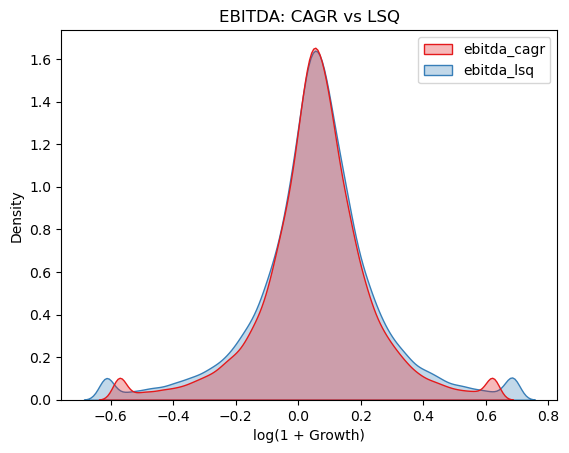

In [177]:
#Distribution of EBITDA CAGR vs LSQ (no-analyst dataset)

sns.kdeplot(wlog(df_1[['ebitda_cagr', 'ebitda_lsq']]), fill=True, alpha=0.3)
plt.xlabel("log(1 + Growth)")
plt.title('EBITDA: CAGR vs LSQ')
plt.show()

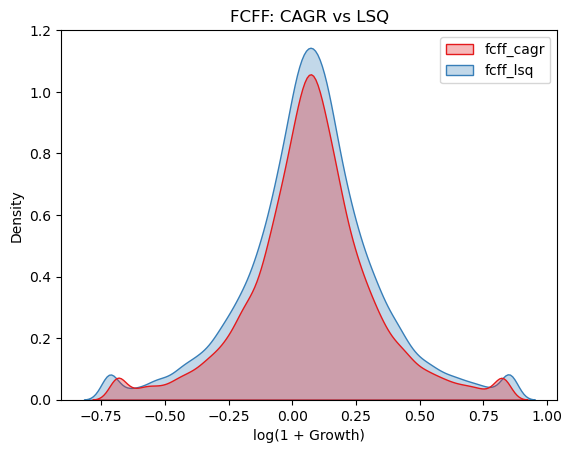

In [178]:
#Distribution of FCFF CAGR vs LSQ (no-analyst dataset)

sns.kdeplot(wlog(df_1[['fcff_cagr', 'fcff_lsq']]), fill=True, alpha=0.3)
plt.xlabel("log(1 + Growth)")
plt.title('FCFF: CAGR vs LSQ')
plt.show()

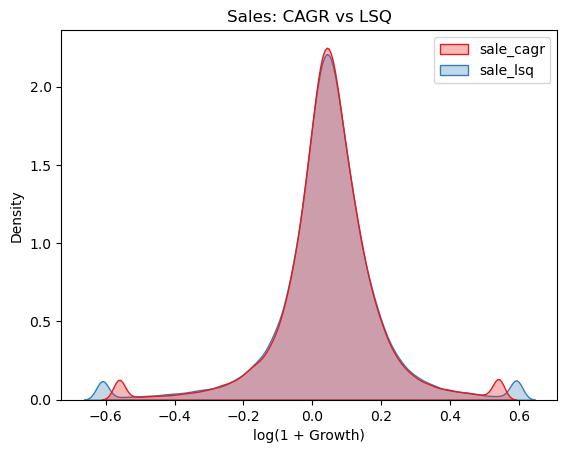

In [179]:
#Distribution of Sales CAGR vs LSQ (no-analyst dataset)

sns.kdeplot(wlog(df_1[['sale_cagr', 'sale_lsq']]), fill=True, alpha=0.3)
plt.xlabel("log(1 + Growth)")
plt.title('Sales: CAGR vs LSQ')
plt.show()

Again, these are similar distributions, but the LSQ calculations have a more pronounced fat tail, especially in the Sale and EBITDA target variable.

Next I will compare the distributions of different target variables in one plot (KDE and Boxplot).

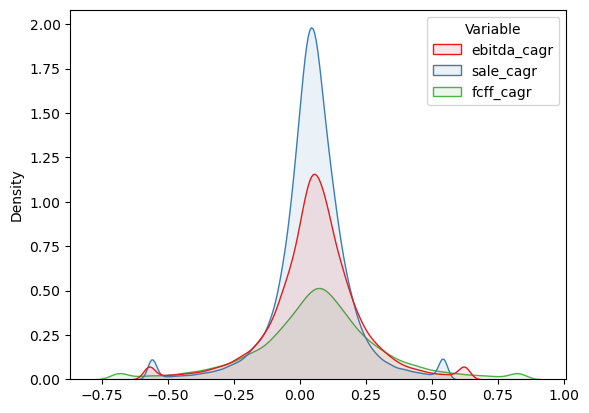

In [180]:
#CAGR for different proxies: 

#Intialize a list to only look at the CAGR target variables
y = []
for i in y_list: 
    x = i.split('_')
    if x[1] != 'lsq':
        y.append(i)

#Set Seaborn palette:
sns.set_palette("Set1")


ax = sns.kdeplot(wlog(df_1[y]), fill=True, alpha=0.1) 
ax.legend_.set_title("Variable")
plt.show()

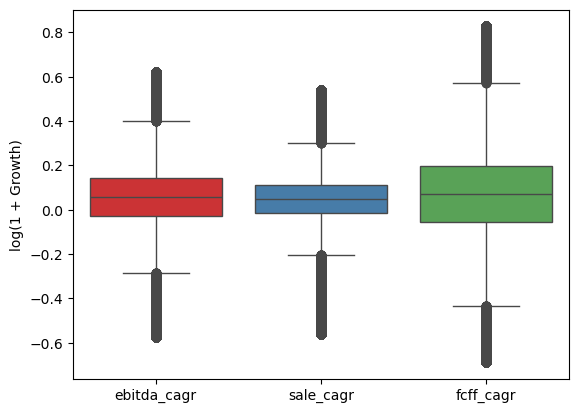

In [181]:
# Look again as a boxplot
sns.boxplot(
    data=wlog(df_1[y]), saturation=0.75)
plt.ylabel("log(1 + Growth)")
plt.xlabel("")
plt.show()

From the KDE Plot one can see huge differences in the distributions of the target variable that were not visible when I compared them in separate plots. The distribution of the FCFF CAGR is far broader than for EBITDA and even more so for the Sales Variable, which is most narrowly distributed. However, from the Median Variable (readable in the Boxplot) one can see that all 3 proxy variables are pretty similar to each other. This leads to the conclusion that one can not only use one of the target variables as a proxy, but note that they tend to behave similarly in the median case.

Furthermore, the distribution of LSQ is examined to see if similar things can be concluded there:

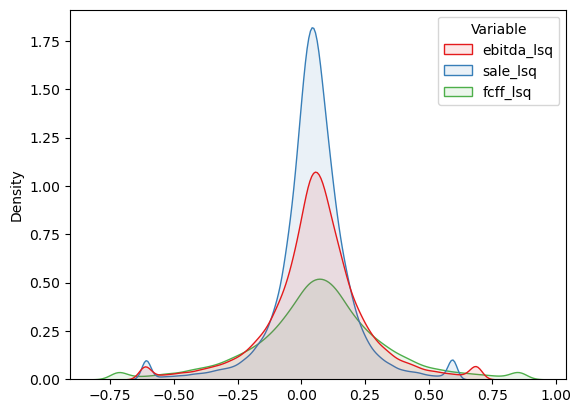

In [182]:
#CAGR for different proxies: 

#Intialize a list to only look at the CAGR target variables
y = []
for i in y_list: 
    x = i.split('_')
    if x[1] == 'lsq':
        y.append(i)

#Set Seaborn palette:
sns.set_palette("Set1")


ax = sns.kdeplot(wlog(df_1[y]), fill=True, alpha=0.1) 
ax.legend_.set_title("Variable")
plt.show()

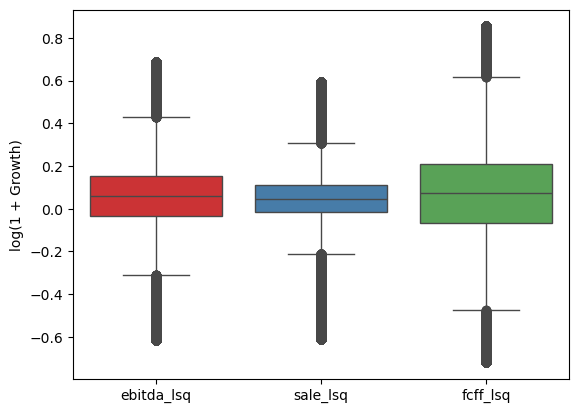

In [183]:
# Look again as a boxplot
sns.boxplot(
    data=wlog(df_1[y]), saturation=0.75)
plt.ylabel("log(1 + Growth)")
plt.xlabel("")
plt.show()

Similar results hold for the LSQ case, which is no surprise! In the further analysis I will therefore only focus on the CAGR calculations for brevity of the EDA notebook. Finally, to round this section off, I plot the Regression results of the LSQ and CAGR calculations against each other to see how similar they are in a visual sense.

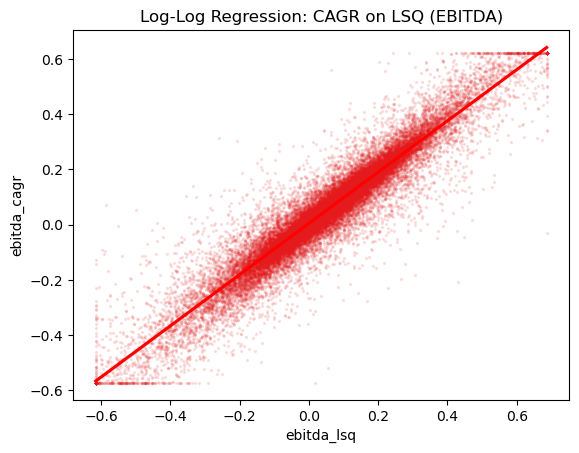

In [184]:
#Regressing ebitda_cagr on ebitda_lsq

sns.regplot(x=wlog(df_1['ebitda_lsq']), y=wlog(df_1['ebitda_cagr']),
            scatter_kws={'s': 2, 'alpha': 0.1}, line_kws={'color': 'r'})
plt.title('Log-Log Regression: CAGR on LSQ (EBITDA)')
plt.show()

One can confidently see that the LSQ variable measures similar performance as the CAGR variable.

### 2.2. Valuation Ratios

While target variable distributions were discussed in section 2.1. of the EDA, this section deals with a different issue, namely the distribution of the valuation variables. The following variables will be explored: B-M, S-P, E-P

For all the ratios I will look at the distribution of the larger dataset without analyst coverage, but I will also look at a dataset where one of the target variables is not missing in an observation.

First of all I have to make a similar decision regarding outlier handling as in section 2.1. Therefore, I will winsorize all variables at the 1% and 99% quantile to look at them. But with the huge difference that the winsorization will be done on a per fiscal year basis, because feature properties can change over time and therefore the distribution of the variables can change as well. If I would cut the outliers on the whole dataset, I would potentially cut outliers that are not outliers in a specific fiscal year.

The following data handling steps are required for the next sections of the EDA:

In [185]:
#Create a dataset where the target variable is not missing for at least one of the proxies. 
df_1a = df_1[(df_1['ebitda_cagr'].notna()) | (df_1['ebitda_lsq'].notna()) | (df_1['fcff_cagr'].notna()) | (df_1['fcff_lsq'].notna()) | (df_1['sale_cagr'].notna()) | (df_1['sale_lsq'].notna())].copy()

#The following variables are not used for the following winsorization because they are either identifiers or macroeconomic variables. 
_ids   = ['gvkey', 'permno', 'fyear', 'gsector', 'sic2', 'type_durable',
          'ebitda_cagr_end', 'sale_cagr_end', 'fcff_cagr_end',
          'ebitda_lsq_nobs', 'sale_lsq_nobs', 'fcff_lsq_nobs']
_macro = ['credit_spread', 'term_spread', 'treasury_yield',
          'inflation_rate_10y', 'gdp_growth_rate_10y']  


# Per Fiscalyear winsorization at 1%/99%

#Replace infinite values with NaN 
df_1a = df_1a.replace([np.inf, -np.inf], np.nan)

#List comprehension to select all the numeric columns that are not in the identifier or macroeconomic variable lists
_num = [c for c in df_1a.select_dtypes(include='number').columns if c not in _ids + _macro]

#For all the columns identified before apply the year-wise winsorization at the 1% and 99% quantile. 
df_1a[_num] = (df_1a.groupby('fyear')[_num]
            .transform(lambda s: s.clip(s.quantile(0.01), s.quantile(0.99))))

#Furthermore we add the sector names to the dataset for better visualization.
gsector_dict = {10: 'Energy', 15: 'Materials', 20: 'Industrials', 25: 'Consumer Discretionary', 30: 'Consumer Staples', 35: 'Health Care', 40: 'Financials', 45: 'Information Technology', 50: 'Communication Services', 55: 'Utilities', 60: 'Real Estate'}

#Map the gsector codes to the sector names
df_1a["sector"] = df_1a["gsector"].map(gsector_dict)

In [186]:
#Set the palette for plotting: 

palette = sns.color_palette("tab20", 10)


**B-M**

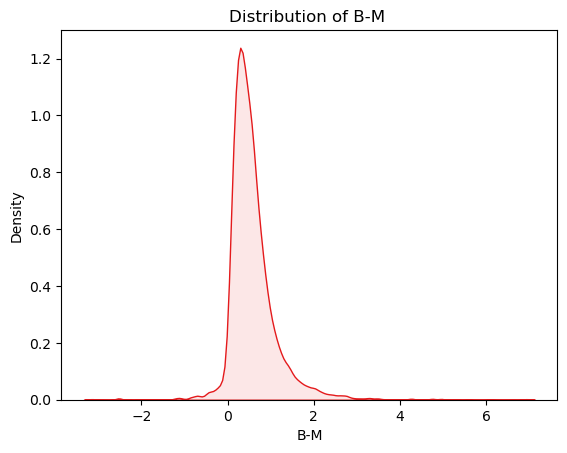

In [187]:
#Plot Distribution B-M 

sns.kdeplot(df_1a['B-M'], fill=True, alpha=0.1)
plt.title('Distribution of B-M ') 
plt.show()


The average B-M according to NYU-Stern lies at about 0.2, where a lot of the underlying data is also concentrated. However, the mean and median here are slightly higher, which can be seen in Section 1. In the next plot I will look if there are distributional differences in B-M between sectors (which is bivariate analysis to be concrete).

/var/folders/kz/cdns3q5j33910y0dt9d7416m0000gn/T/ipykernel_4114/857672723.py:2: UserWarning: 
The palette list has fewer values (10) than needed (11) and will cycle, which may produce an uninterpretable plot.
  ax = sns.kdeplot(


Text(0.5, 1.0, 'Distribution of B-M by Sector')

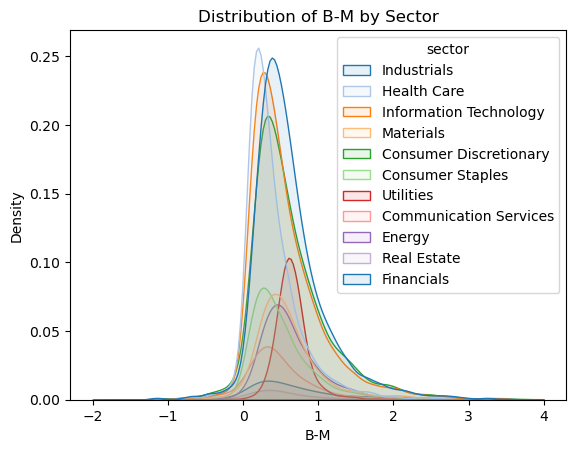

In [188]:
#Plot the distribution of B-M by sector
ax = sns.kdeplot(
    data=df_1a,
    x='B-M',
    hue='sector',
    fill=True,
    palette=palette,
    clip=(-2, 4),
    alpha=0.1)

plt.title('Distribution of B-M by Sector')



As can be seen, the distributions of B-M vary considerably between different sectors. For instance, distributions are way thinner for the Utilities sector compared to Industrial or Information Technology sectors for example.

**S-P**

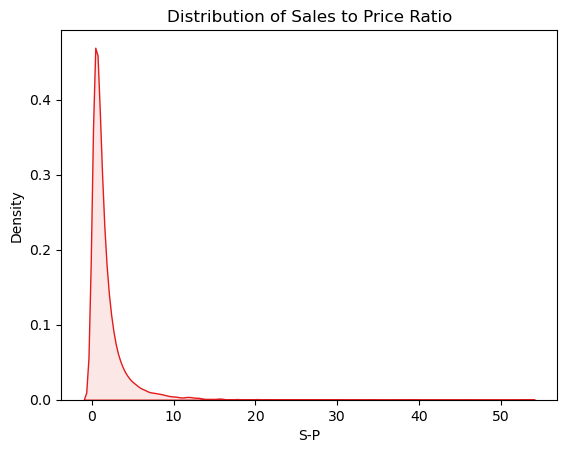

In [189]:
#Plot Distribution S-P

sns.kdeplot(df_1a['S-P'], fill=True, alpha=0.1) 
plt.title('Distribution of Sales to Price Ratio')
plt.show()


Sales to price is highly right-skewed and would therefore benefit from a log transformation.

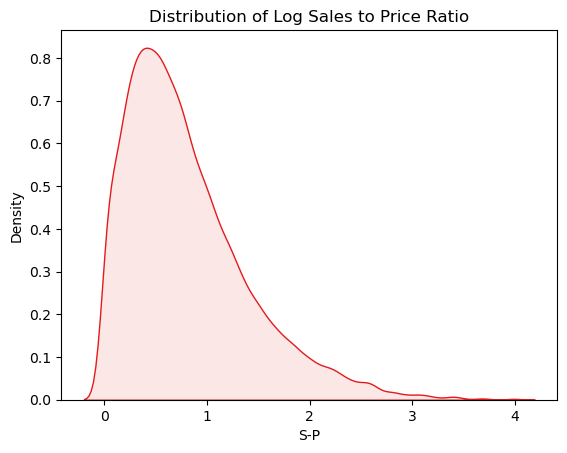

In [190]:

sns.kdeplot(np.log1p(df_1a['S-P']), fill=True, alpha=0.1) 
plt.title('Distribution of Log Sales to Price Ratio')
plt.show()

This significantly helps to make the distribution more normal but it still has a right skewed distribution. Let's look at which sectors have a higher S-P Ratio.

/var/folders/kz/cdns3q5j33910y0dt9d7416m0000gn/T/ipykernel_4114/2669680750.py:4: UserWarning: 
The palette list has fewer values (10) than needed (11) and will cycle, which may produce an uninterpretable plot.
  ax = sns.kdeplot(


Text(0.5, 1.0, 'Distribution of S-P by Sector')

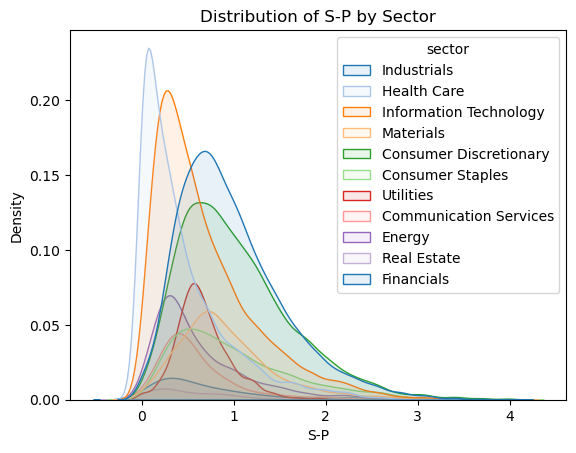

In [191]:
#Plot the distribution of S-P by sector


ax = sns.kdeplot(
    data=df_1a,
    x=np.log1p(df_1a['S-P']),
    hue='sector',
    fill=True,
    palette=palette,
    alpha=0.1)

plt.title('Distribution of S-P by Sector')


There is quite some divergence between sectors. For instance the Information Technology sector is more concentrated on higher S-P ratios with higher right-skewed tails, where Consumer Staples are more in the lower S-P ratio range. While sector divergence is here more visible than for B-M, all the S-P distributions are still right-skewed even after the log transformation.

**E-P**

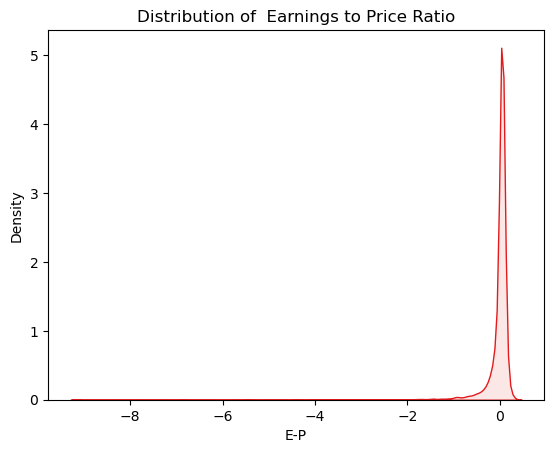

In [192]:
sns.kdeplot(df_1a['E-P'], fill=True, alpha=0.1) 
plt.title('Distribution of  Earnings to Price Ratio')
plt.show()

One can see a highly left-skewed distribution of the E-P data, which is not surprising since roughly one-third of the companies have negative earnings. This is a problem for data preprocessing since log transformations cannot be used to make the distribution more normal for instance.

Let's look at the Divergence per Sector.

/var/folders/kz/cdns3q5j33910y0dt9d7416m0000gn/T/ipykernel_4114/671763951.py:3: UserWarning: 
The palette list has fewer values (10) than needed (11) and will cycle, which may produce an uninterpretable plot.
  ax = sns.kdeplot(


Text(0.5, 1.0, 'Distribution of E-P by Sector')

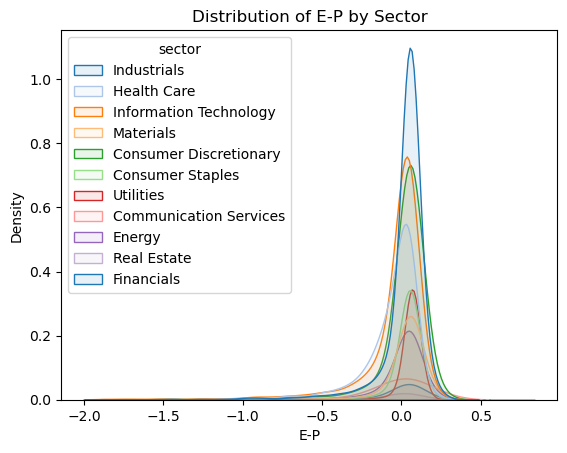

In [193]:
#Plot the distribution of E-P by sector

ax = sns.kdeplot(
    data=df_1a,
    x=df_1a['E-P'],
    hue='sector',
    fill=True,
    palette=palette,
    clip=(-2, 4),
    alpha=0.1)

plt.title('Distribution of E-P by Sector')


Again distributional differences that are not easily readable, therefore the median per sector is additionally examined to see if there are any differences in the central tendency of the E-P ratio.

In [194]:
df_1a.groupby('sector')['E-P'].median().sort_values(ascending=False)

sector
Utilities                 0.065890
Materials                 0.052125
Consumer Discretionary    0.050525
Industrials               0.050080
Consumer Staples          0.050028
Financials                0.040399
Energy                    0.037045
Communication Services    0.028346
Information Technology    0.023141
Real Estate               0.011253
Health Care              -0.002301
Name: E-P, dtype: float64

In line with economic expectations, the sectors with the highest median E-P ratios are rather defensive sectors like Utilities. The most expensive profitable sector (excluding leftovers from Real Estate) is Information Technology. Health Care is on average even negative (unprofitable).

### 2.3. Market Ratios

**Beta**

Let's look at the distribution of Beta.

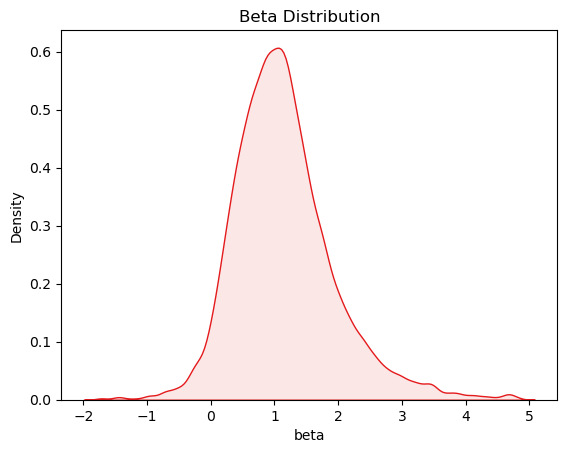

In [195]:
#Plot the distribution of Beta
sns.kdeplot(df_1a['beta'], fill=True, alpha=0.1) 
plt.title('Beta Distribution')
plt.show()

Well behaved around 1, which makes economic sense, no preprocessing that will change the distributional shape is needed. Let's look at the distribution of Beta by sector.

/var/folders/kz/cdns3q5j33910y0dt9d7416m0000gn/T/ipykernel_4114/3158917560.py:3: UserWarning: 
The palette list has fewer values (10) than needed (11) and will cycle, which may produce an uninterpretable plot.
  ax = sns.kdeplot(


Text(0.5, 1.0, 'Distribution of Beta by Sector')

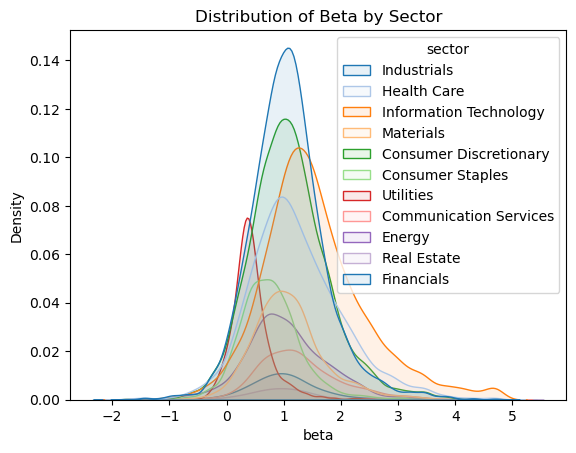

In [196]:
#Plot the distribution of Beta by sector

ax = sns.kdeplot(
    data=df_1a,
    x=df_1a['beta'],
    hue='sector',
    fill=True,
    palette=palette,
    alpha=0.1)

plt.title('Distribution of Beta by Sector')


The sector divergence of beta is clearly visible. Again, the Information Technology sector has a higher right-skewed distribution than the more defensive sectors like Utilities, Consumer Staples or Communication Services.

### 2.4. Profitability Ratios

In this EDA section I take a closer look at profitability measures, which had, as previously stated, a massive impact on the survivorship bias in the dataset.

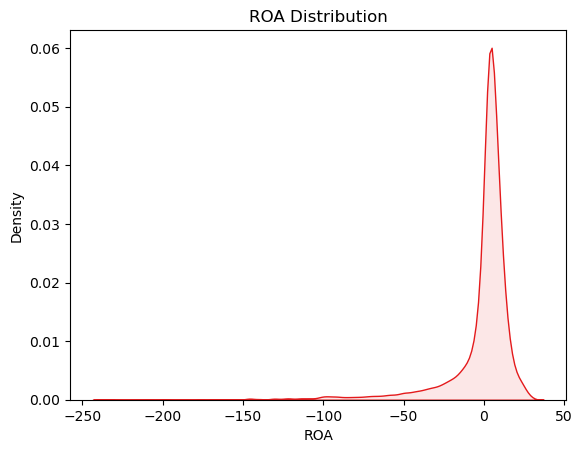

In [197]:
#Plot the distribution of ROA
sns.kdeplot(df_1a['ROA'], fill=True, alpha=0.1) 
plt.title('ROA Distribution')
plt.show()

/var/folders/kz/cdns3q5j33910y0dt9d7416m0000gn/T/ipykernel_4114/2990424140.py:3: UserWarning: 
The palette list has fewer values (10) than needed (11) and will cycle, which may produce an uninterpretable plot.
  ax = sns.kdeplot(


Text(0.5, 1.0, 'Distribution of ROA by Sector')

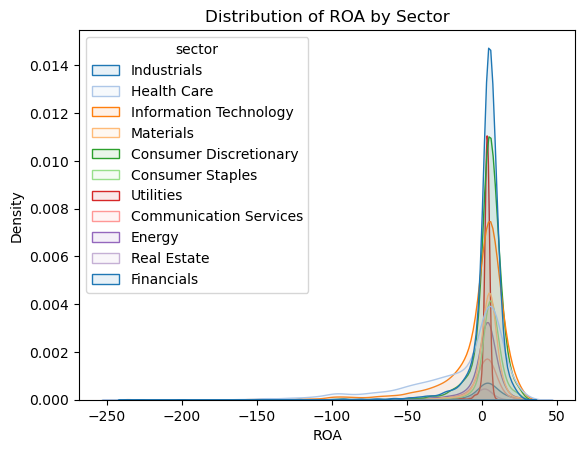

In [198]:
#Plot the distribution of ROA by sector

ax = sns.kdeplot(
    data=df_1a,
    x=df_1a['ROA'],
    hue='sector',
    fill=True,
    palette=palette,
    alpha=0.1)

plt.title('Distribution of ROA by Sector')


One can see that the ROA distribution is highly left skewed, some sectors like Health Care and Information Technology have fatter left tails than others.

Note: a similar picture can be drawn from looking at ROE, therefore this variable will not be further discussed in this section.

### 2.5. Horizon Window

This section differs a bit from the previous ones, because it will not look at distributional properties of the data, but rather if most of the Horizon Windows analysed are not affected by the fallback decision implemented in the Data Preparation notebook and further discussed in the thesis. In an optimal scenario, most of the observations have an ending horizon of 10 years, and only a few, more recent, observations have a fallback ending horizon of 9 or 8 years.

To analyse this, I plot a barplot for the different horizon windows per target variable.

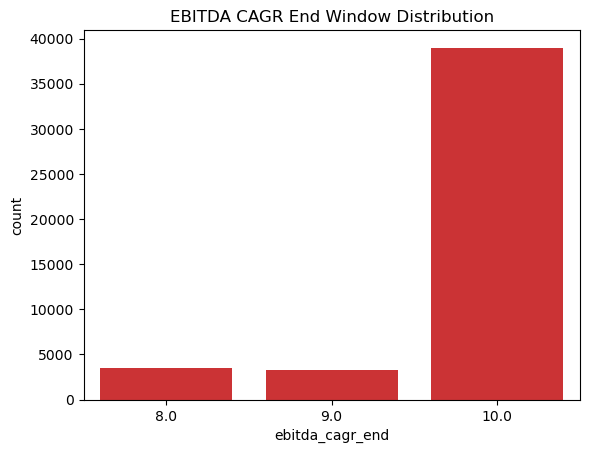

In [199]:
#Barplot of the EBITDA CAGR End window for the the datasets. The barplot shows the percentage of observations that fall into the different target horizons.
sns.barplot(df_1a['ebitda_cagr_end'].value_counts())
plt.title('EBITDA CAGR End Window Distribution')
plt.show()

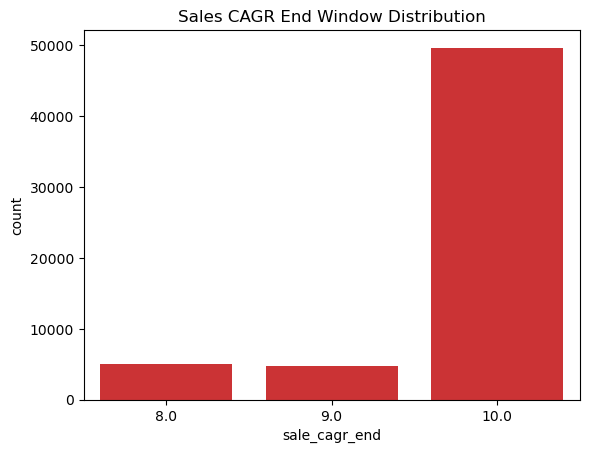

In [200]:
#Barplot of the Sales CAGR End window for the the datasets. The barplot shows the percentage of observations that fall into the different target horizons.
sns.barplot(df_1a['sale_cagr_end'].value_counts())
plt.title('Sales CAGR End Window Distribution')
plt.show()

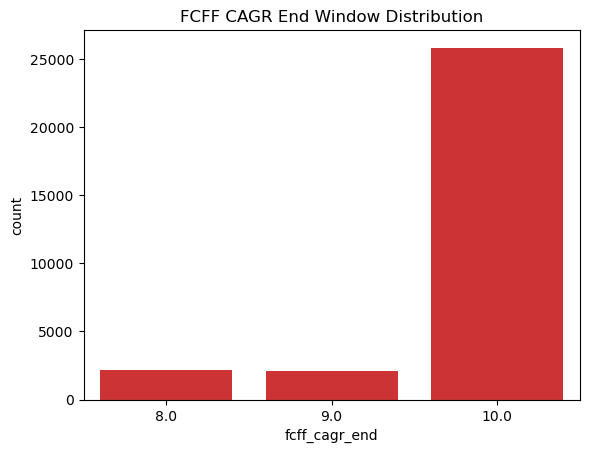

In [201]:
sns.barplot(df_1a['fcff_cagr_end'].value_counts())
plt.title('FCFF CAGR End Window Distribution')
plt.show()

Although relaxing the target horizon constraint, most observations still fall into the 10 year ending horizon, which is a great sign!

**Conclusion:** The univariate EDA section has shown that LSQ vs CAGR calculations have a similar distributional behaviour, while diverging a bit in the tails. A similar picture can be drawn for the general conclusion of the target variables in the dataset with and without analyst coverage. Regarding the Feature Analysis in Section 2.2. to 2.4., one important insight is that the distributions of the features are highly sector dependent. Finally, Section 2.5. shows that most of the observations with target variables fall in the planned ending horizon and are not affected by the fallback decision.

---

## **3. Bivariate Data Analysis**

In section 3 of the EDA, I will first of all look at the correlation structures of the features and the target variables (3.1.). Further, I will look at the distribution of the target variables by important categories and further bivariate distributions in 3.2. and 3.3. Most important to this thesis, section 3.4. will study the mean-reversion aspects of growth rates, which plays an important part in the economic theory of this thesis. To conclude, section 3.5. will look at time-varying properties of the EDA, to see if the data insights are robust over time.

### 3.1. Correlation Analysis

One big correlation matrix over all numeric features and the target variables would not be visually appealing. Therefore, I created sub-correlation structures categorized by feature sets (Valuation & Market Features, Profitability & Time Series Features, Macroeconomic Features, Industry Ratios & Analyst Features).

In [202]:
# Correlation matrix between target variables and features

# The correlation matrix can only be calculated for numeric features. Therefore, I select only the numeric features from the dataset and form a new EDA dataframe
df1b = df_1a.select_dtypes(include="number").copy()



**Valuation & Market Features**

Text(0.5, 1.0, 'Correlation Matrix - Valuation & Market Variables')

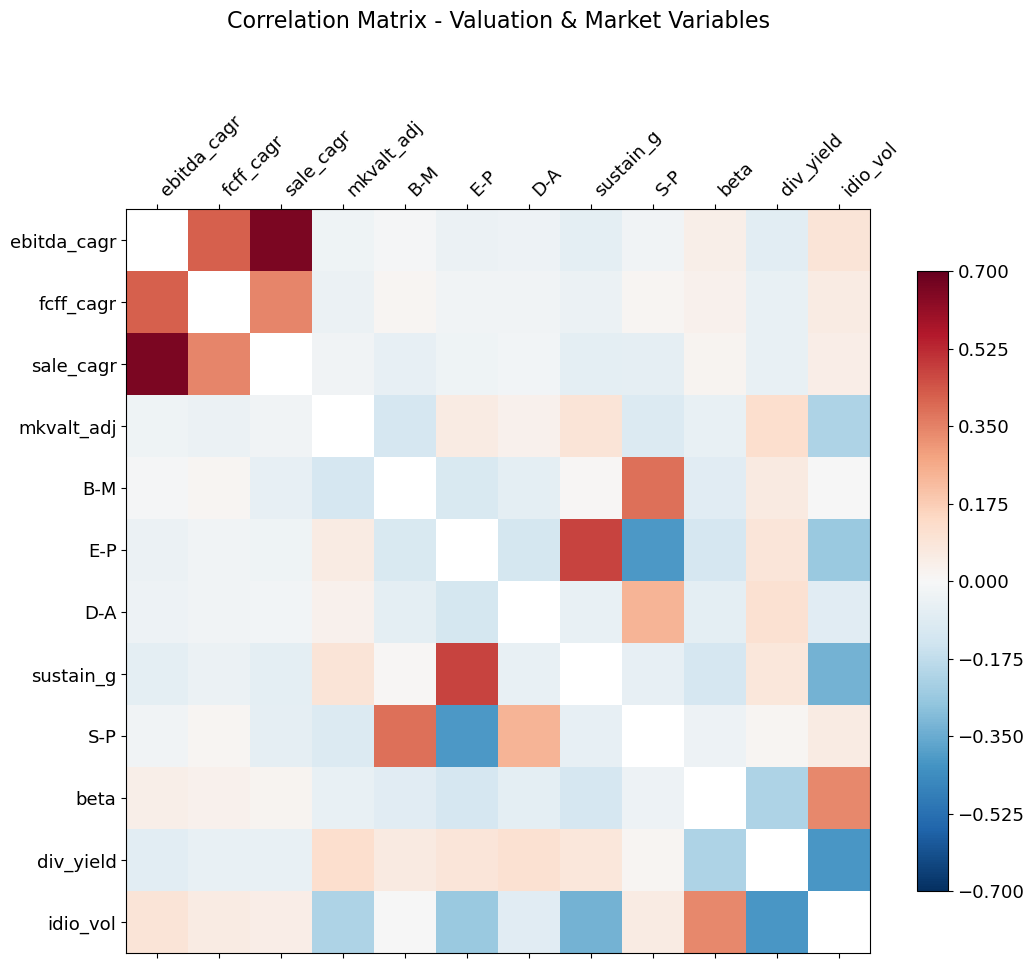

In [203]:
#Columns to be included in the correlation matrix. 
cols = ['ebitda_cagr', 'fcff_cagr', 'sale_cagr', 'mkvalt_adj', 'B-M', 'E-P', 'D-A', 'sustain_g', 'S-P', 'beta', 'div_yield', 'idio_vol']

#Build the correlation matrix with the respectively selected columns.
corr = df1b[cols].corr()
#Set the diagonal to NaN (self-correlation of features is not informative for the correlation analysis)
np.fill_diagonal(corr.values, np.nan)     

#Ensure a symmetric colorbar 
v = np.ceil(np.nanmax(np.abs(corr.values)) * 20) / 20   

#Show the correlation matrix with the feature names on the x and y axis. 
f = plt.figure(figsize=(12, 10))
plt.matshow(corr, fignum=f.number, cmap='RdBu_r', vmin=-v, vmax=v)
plt.xticks(range(len(cols)), cols, fontsize=13, rotation=45, ha='left')
plt.yticks(range(len(cols)), cols, fontsize=13)

#Legend
cb = plt.colorbar(ticks=np.arange(-v, v + 1e-9, v/4), shrink=0.8)
cb.ax.tick_params(labelsize=13)

plt.title('Correlation Matrix - Valuation & Market Variables', fontsize=16, pad=60)

As can be seen in the correlation matrix there is only a weak linear relationship between the firm ratios and the target variables, while there is some collinearity in the feature set, the target variables seem to be rather linearly independent from the firm ratios. The greatest impact have the dividend yield, the sustainable growth rate as well as the beta and idiosyncratic volatility. Making the prediction of the target variables with linear models like linear regression from the firm ratios a non-trivial task.

**Firm Ratios (Profitability & Lagged Growth)**

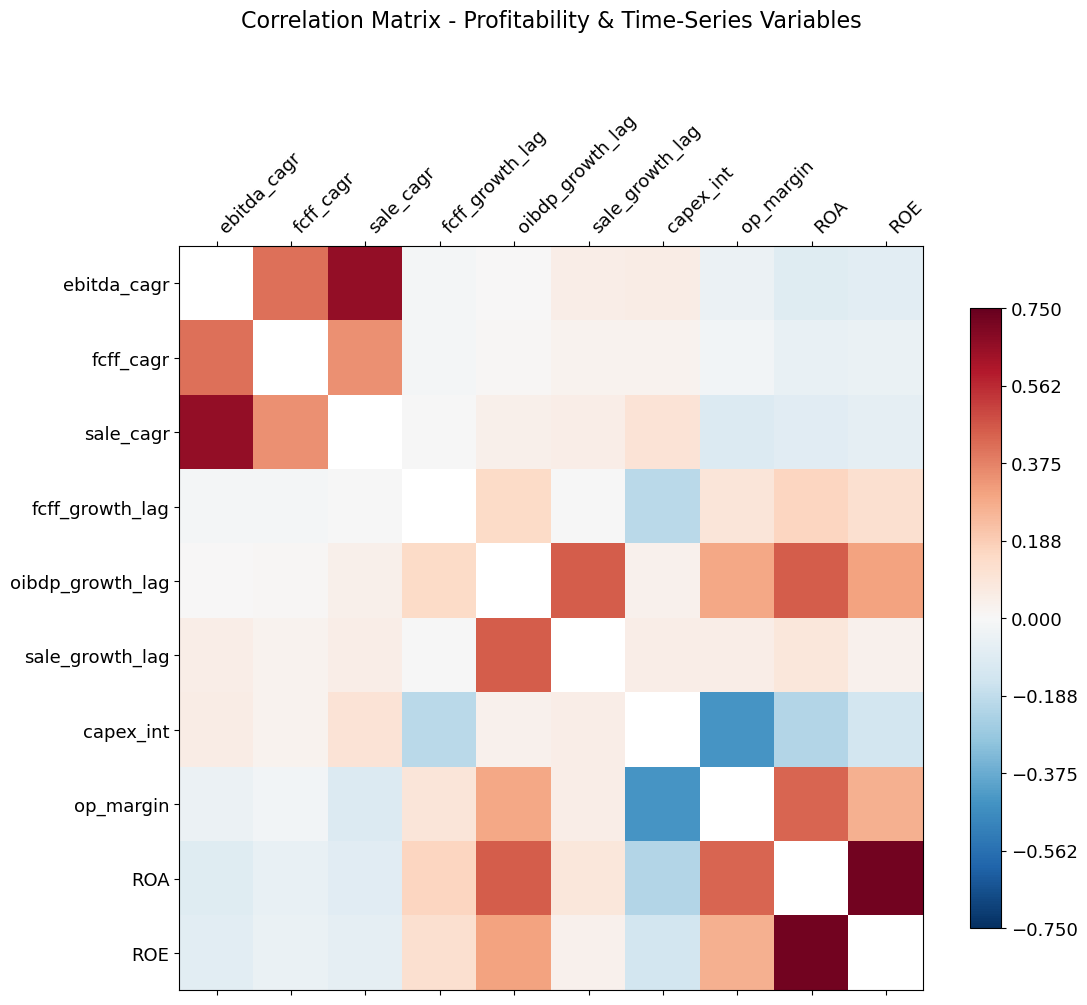

In [204]:
#Columns to be included in the correlation matrix. 
cols = ['ebitda_cagr', 'fcff_cagr', 'sale_cagr', 'fcff_growth_lag', 'oibdp_growth_lag', 'sale_growth_lag', 'capex_int', 'op_margin', 'ROA', 'ROE']

#Build the correlation matrix with the respectively selected columns.
corr = df1b[cols].corr()

#Set the diagonal to NaN (self-correlation of features is not informative for the correlation analysis)
np.fill_diagonal(corr.values, np.nan)  

#Ensure a symmetric colorbar 
v = np.ceil(np.nanmax(np.abs(corr.values)) * 20) / 20   

#Show the correlation matrix with the feature names on the x and y axis. 
f = plt.figure(figsize=(12, 10))
plt.matshow(corr, fignum=f.number, cmap='RdBu_r', vmin=-v, vmax=v)
plt.xticks(range(len(cols)), cols, fontsize=13, rotation=45, ha='left')
plt.yticks(range(len(cols)), cols, fontsize=13)

#Legend
cb = plt.colorbar(ticks=np.arange(-v, v + 1e-9, v/4), shrink=0.8)
cb.ax.tick_params(labelsize=13)

plt.title('Correlation Matrix - Profitability & Time-Series Variables', fontsize=16, pad=60);

A somewhat clearer picture is visible with the time series and profitability ratios. It can be seen that the lagged sale growth as well as the CAPEX intensity have some impact on the target variables, while also the profitability features demonstrate some correlation with the target variables.

**Industry Ratios**

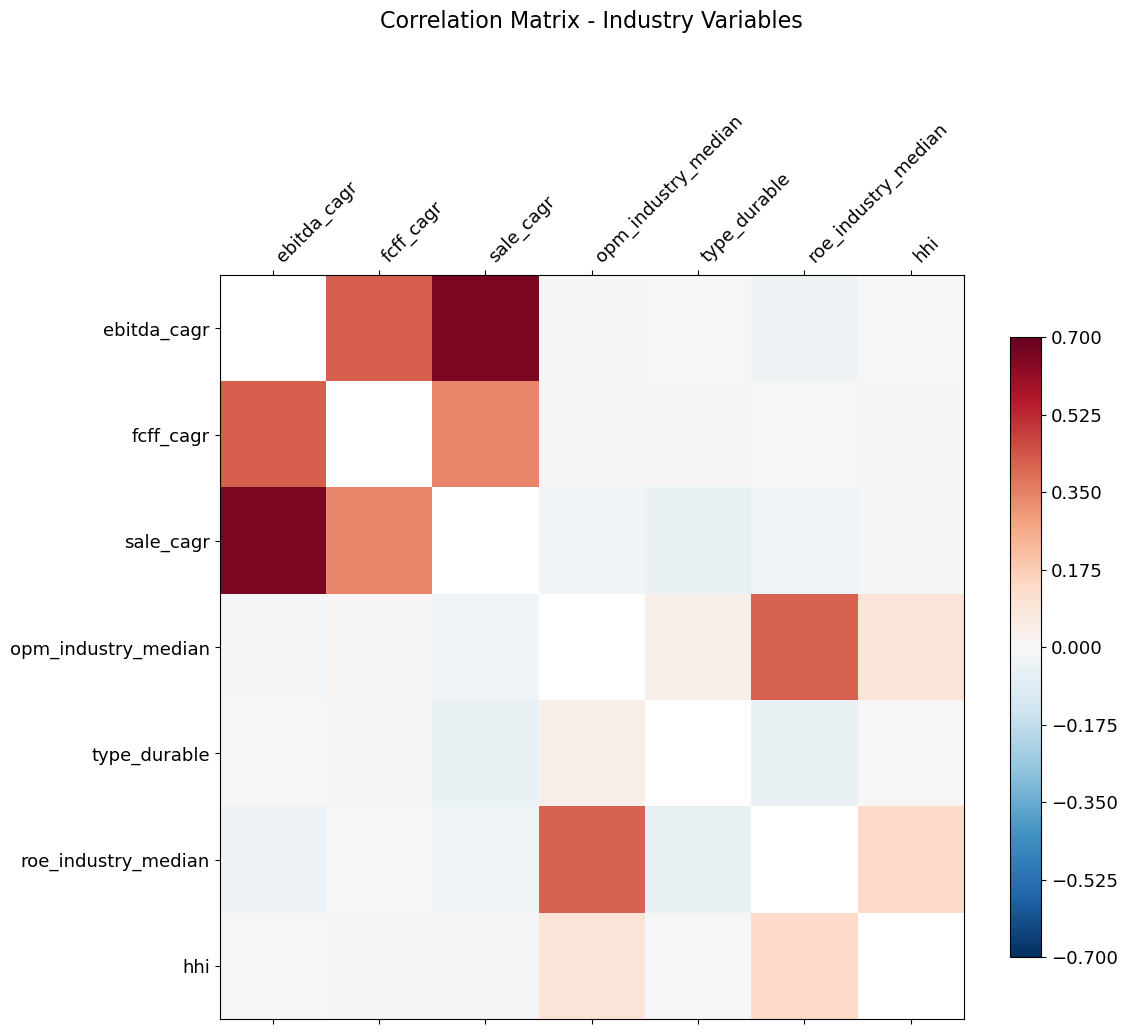

In [205]:
#Columns to be included in the correlation matrix. 
cols = ['ebitda_cagr', 'fcff_cagr', 'sale_cagr', 'opm_industry_median', 'type_durable', 'roe_industry_median', 'hhi']

#Build the correlation matrix with the respectively selected columns.
corr = df1b[cols].corr()

#Set the diagonal to NaN (self-correlation of features is not informative for the correlation analysis)
np.fill_diagonal(corr.values, np.nan)  

#Ensure a symmetric colorbar 
v = np.ceil(np.nanmax(np.abs(corr.values)) * 20) / 20   

#Show the correlation matrix with the feature names on the x and y axis. 
f = plt.figure(figsize=(12, 10))
plt.matshow(corr, fignum=f.number, cmap='RdBu_r', vmin=-v, vmax=v)
plt.xticks(range(len(cols)), cols, fontsize=13, rotation=45, ha='left')
plt.yticks(range(len(cols)), cols, fontsize=13)

#Legend
cb = plt.colorbar(ticks=np.arange(-v, v + 1e-9, v/4), shrink=0.8)
cb.ax.tick_params(labelsize=13)

plt.title('Correlation Matrix - Industry Variables', fontsize=16, pad=60);

While the previous ratios have some (linear) impact on the target variables, the industry ratios that are stemming from academic and economical research seem to have almost no linear impact on the target variables of this thesis. Therefore, the industry features should not be a good predictor, at least in a linear sense, for the target variables.

**Macroeconomic Ratios**

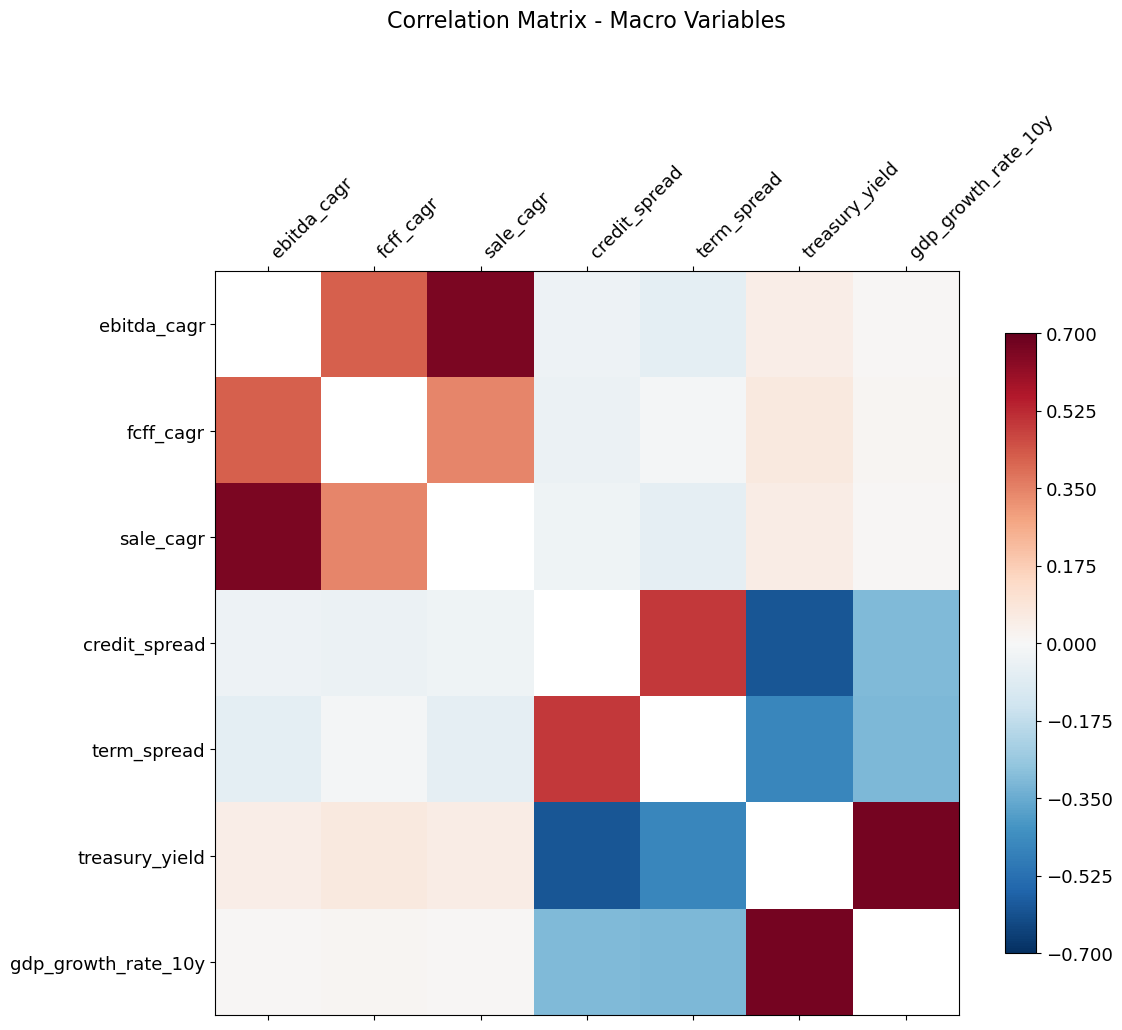

In [206]:
#Columns to be included in the correlation matrix. 
cols = ['ebitda_cagr', 'fcff_cagr', 'sale_cagr', 'credit_spread', 'term_spread', 'treasury_yield', 'gdp_growth_rate_10y']


#Build the correlation matrix with the respectively selected columns.
corr = df1b[cols].corr()

#Set the diagonal to NaN (self-correlation of features is not informative for the correlation analysis)
np.fill_diagonal(corr.values, np.nan) 
         
#Ensure a symmetric colorbar 
v = np.ceil(np.nanmax(np.abs(corr.values)) * 20) / 20   

#Show the correlation matrix with the feature names on the x and y axis. 
f = plt.figure(figsize=(12, 10))
plt.matshow(corr, fignum=f.number, cmap='RdBu_r', vmin=-v, vmax=v)
plt.xticks(range(len(cols)), cols, fontsize=13, rotation=45, ha='left')
plt.yticks(range(len(cols)), cols, fontsize=13)

#Legend
cb = plt.colorbar(ticks=np.arange(-v, v + 1e-9, v/4), shrink=0.8)
cb.ax.tick_params(labelsize=13)
plt.title('Correlation Matrix - Macro Variables', fontsize=16, pad=60);

The treasury yield and the term spread seem to have some linear impact on the target variables, while the other macroeconomic ratios seem to be rather linearly independent from the Growth rate.

**Analyst Ratios**

To analyse the impact of the analyst ratios on the target variables, I have to create a new EDA dataframe because the other winsorized one was created on the data without analyst coverage. Therefore, in a first step the same winsorization methods as discussed before will be applied to the analyst covered dataset. After that, I will look at the correlation structure of the analyst ratios with the target variables.

In [207]:
#First I have to build the Anaylst Dataset 

#Dataset with Analyst Coverage and at least one of the target variables available.
df_a1 = df_a[(df_a['ebitda_cagr'].notna()) | (df_a['ebitda_lsq'].notna()) | (df_a['fcff_cagr'].notna()) | (df_a['fcff_lsq'].notna()) | (df_a['sale_cagr'].notna()) | (df_a['sale_lsq'].notna())].copy()

#The following variables are not used for the following winsorization because they are either identifiers or macroeconomic variables.
_ids   = ['gvkey', 'permno', 'fyear', 'gsector', 'sic2', 'type_durable',
          'ebitda_cagr_end', 'sale_cagr_end', 'fcff_cagr_end',
          'ebitda_lsq_nobs', 'sale_lsq_nobs', 'fcff_lsq_nobs']
_macro = ['credit_spread', 'term_spread', 'treasury_yield',
          'inflation_rate_10y', 'gdp_growth_rate_10y']   

# Per Fiscalyear winsorization at 1%/99%
df_a1 = df_a1.replace([np.inf, -np.inf], np.nan)
_num = [c for c in df_a1.select_dtypes(include='number').columns if c not in _ids + _macro]
df_a1[_num] = (df_a1.groupby('fyear')[_num]
            .transform(lambda s: s.clip(s.quantile(0.01), s.quantile(0.99))))

#Furthermore we add the sector names to the dataset for better visualization.
gsector_dict = {10: 'Energy', 15: 'Materials', 20: 'Industrials', 25: 'Consumer Discretionary', 30: 'Consumer Staples', 35: 'Health Care', 40: 'Financials', 45: 'Information Technology', 50: 'Communication Services', 55: 'Utilities', 60: 'Real Estate'}
df_a1["sector"] = df_a1["gsector"].map(gsector_dict)

#Select only the numeric columns from the dataset for correlation analysis.
df_a1 = df_a1.select_dtypes(include="number")

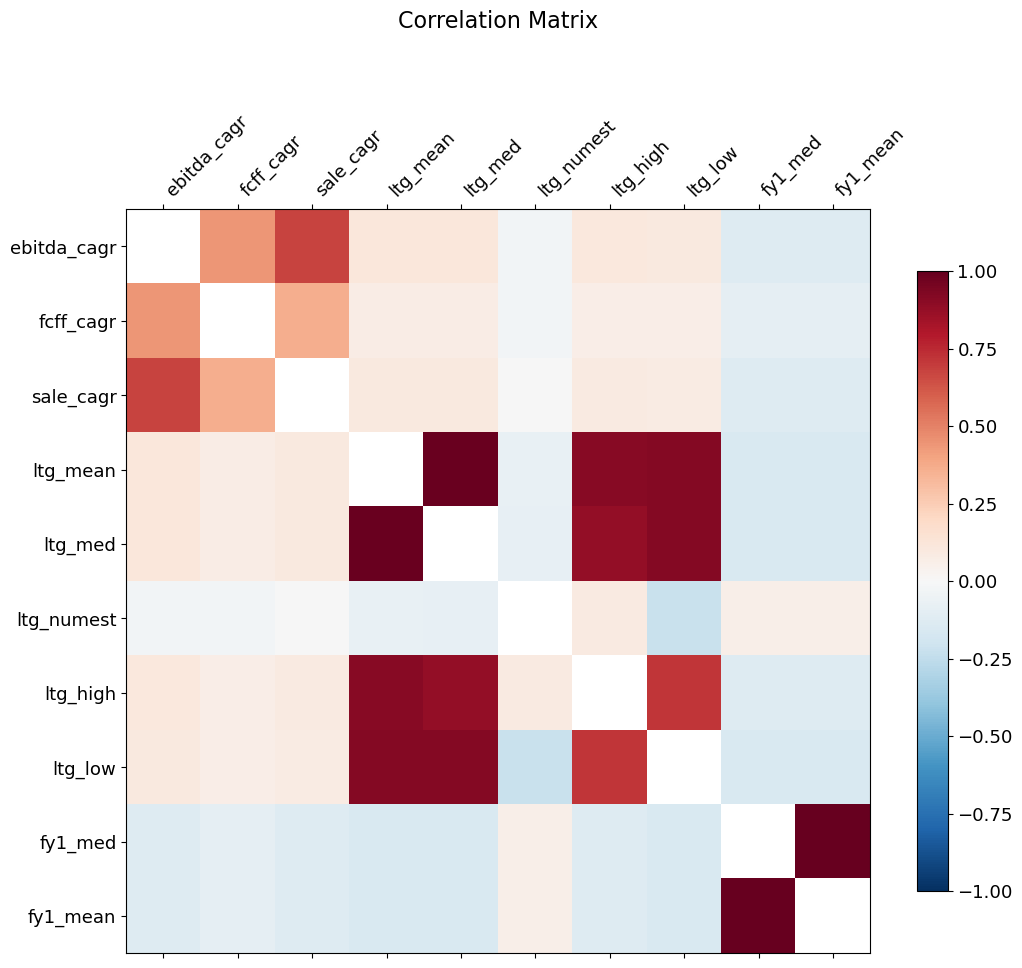

In [208]:
#Columns to be included in the correlation matrix. 
cols = ['ebitda_cagr', 'fcff_cagr', 'sale_cagr', 'ltg_mean', 'ltg_med', 'ltg_numest', 'ltg_high', 'ltg_low', 'fy1_med', 'fy1_mean']

#Build the correlation matrix with the respectively selected columns.
corr = df_a1[cols].corr()

#Set the diagonal to NaN (self-correlation of features is not informative for the correlation analysis)
np.fill_diagonal(corr.values, np.nan)  

#Ensure a symmetric colorbar 
v = np.ceil(np.nanmax(np.abs(corr.values)) * 20) / 20   

#Show the correlation matrix with the feature names on the x and y axis. 
f = plt.figure(figsize=(12, 10))
plt.matshow(corr, fignum=f.number, cmap='RdBu_r', vmin=-v, vmax=v)
plt.xticks(range(len(cols)), cols, fontsize=13, rotation=45, ha='left')
plt.yticks(range(len(cols)), cols, fontsize=13)

#Legend
cb = plt.colorbar(ticks=np.arange(-v, v + 1e-9, v/4), shrink=0.8)
cb.ax.tick_params(labelsize=13)
plt.title('Correlation Matrix', fontsize=16, pad=60);

The Correlation Structure shows that LTG Analyst Estimates seem to have a positive impact on the Realized Growth Rates, while the 1 Year Ahead estimates are negatively correlated with the target variable, possibly due to mean-reversion. This justifies the additional use of the smaller Analyst Dataset, since the LTG Estimates are not available in the larger dataset without analyst coverage but are crucial for the prediction of the target variables.

### 3.2. Distribution of Growth Rate by Important Categories

While Section 2.1. looked at the distributions of the target variables in a univariate sense, this section will look at the distributions categorized by important features like Sectors or Firm Life Cycle Stages. The following plots will show the distribution of the target variables by the respective categories.

**Sector Growth Rate Distributions**

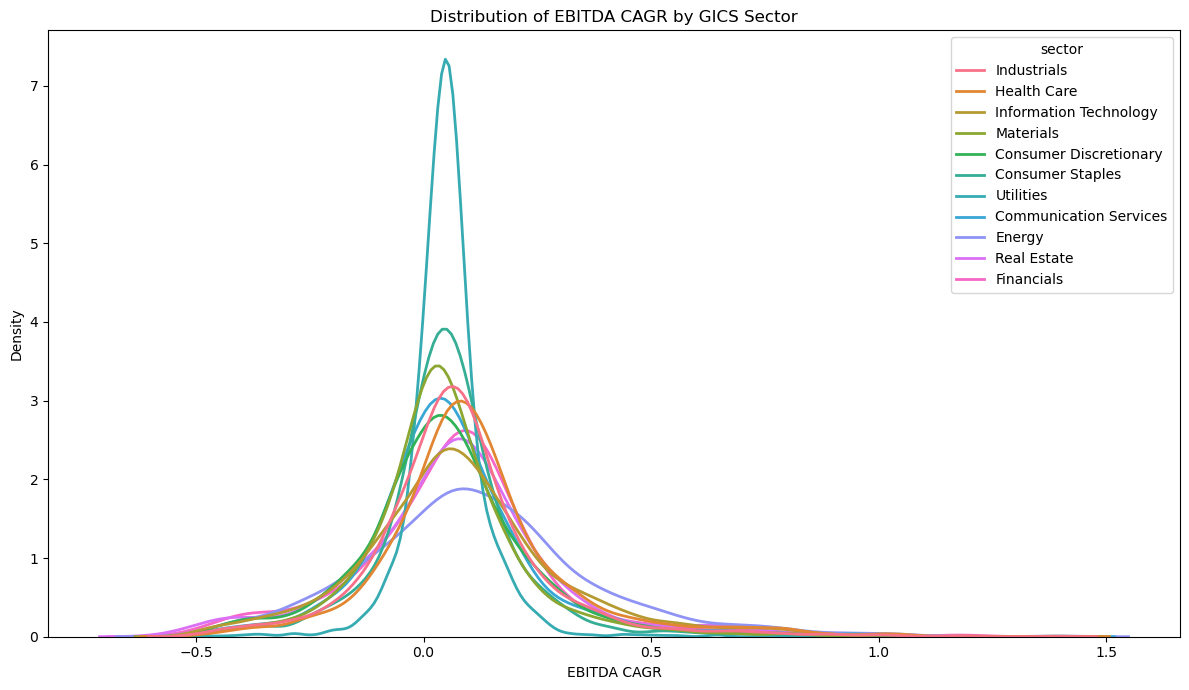

In [209]:
#Plot the distribution of EBITDA CAGR by GICS Sector. 
plt.figure(figsize=(12,7))

sns.kdeplot(
    data=df_1a,
    x='ebitda_cagr',
    hue='sector',
    common_norm=False,
    fill=False,
    linewidth=2
)

plt.xlabel("EBITDA CAGR")
plt.ylabel("Density")
plt.title("Distribution of EBITDA CAGR by GICS Sector")
plt.tight_layout()
plt.show()

A similar conclusion regarding distribution characterization by sector can be drawn for the growth rates compared to the other features in Section 2: most of the sectors have similar distribution structures, but there are some sectors (e.g. Utilities) that have a much narrower distribution of the growth rates, while other sectors like Information Technology & Energy are more volatile. This highlights that the sector variable can potentially be a useful predictor to distinguish between the growth rates of different sectors. In general the distribution of the growth rates is right-skewed, with more outliers in the upper tail than in the lower tail.

**Lifecycle Growth Rate Distributions**

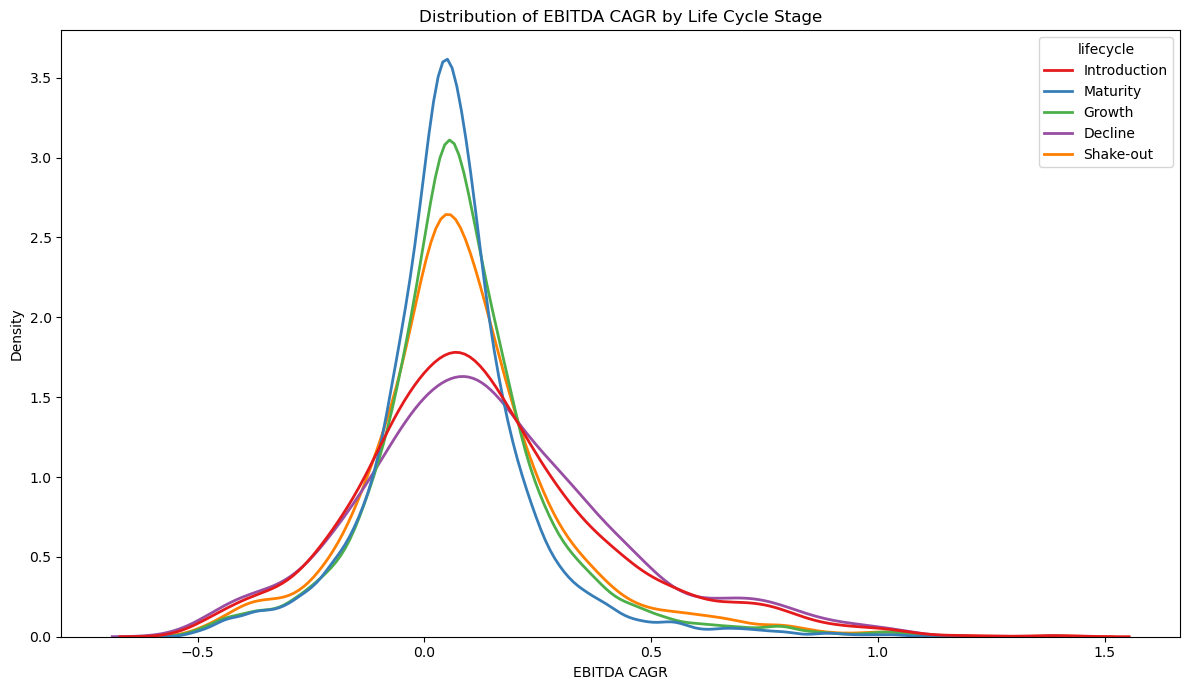

In [210]:
#Plot the distribution of EBITDA CAGR by Life Cycle Stage. 

plt.figure(figsize=(12,7))

sns.kdeplot(
    data=df_1a,
    x='ebitda_cagr',
    hue='lifecycle',
    common_norm=False,
    fill=False,
    linewidth=2
)

plt.xlabel("EBITDA CAGR")
plt.ylabel("Density")
plt.title("Distribution of EBITDA CAGR by Life Cycle Stage")
plt.tight_layout()
plt.show()

In general it can be seen that the Maturity stage is less fat-tailed than the other stages. Especially the Decline and Introduction stage have a much more fat-tailed distribution of the growth rates, which could be a problem for the machine learning models since, as previously discussed, there are far fewer observations in the Decline and Introduction stage and additionally the fat-tailed distribution in the stages itself could act as an additional source of noise.

Overall, the lifecycle variable can be a potentially useful predictor to distinguish between the growth rates of different lifecycle stages, however, the predictions for the Maturity and Growth stages should be more reliable.

**Durable Growth Rate Distributions**

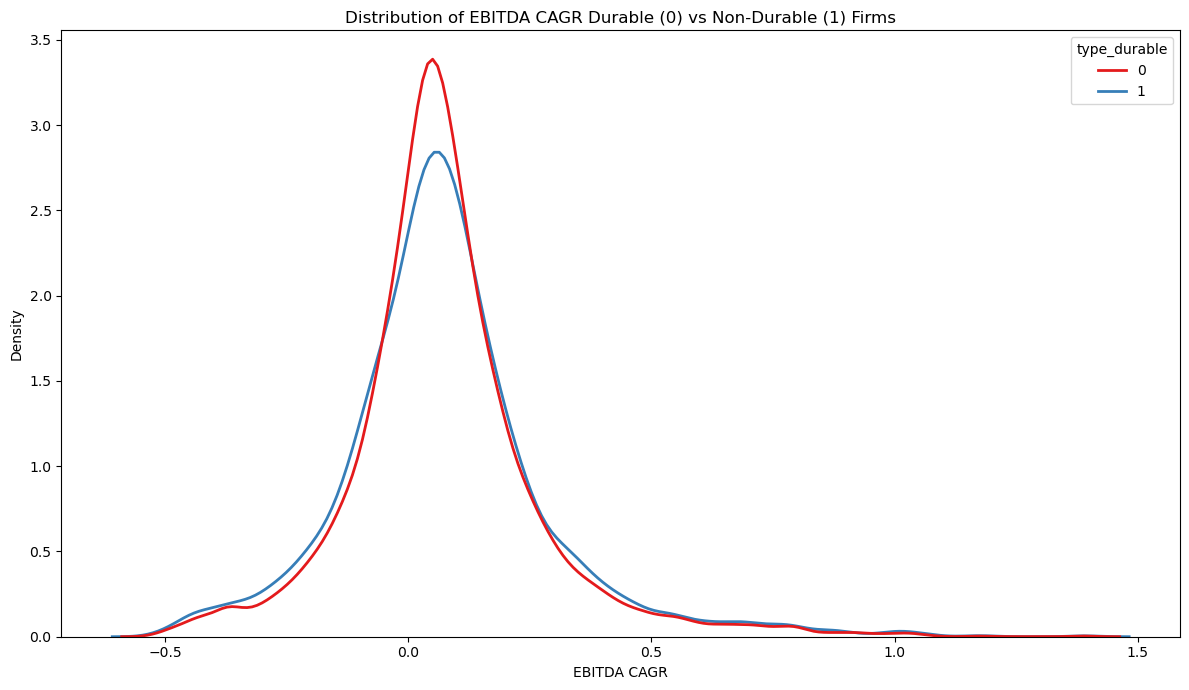

In [211]:
#Plot the distribution of EBITDA CAGR by Durable (0) vs Non-Durable (1) Firms


plt.figure(figsize=(12,7))

sns.kdeplot(
    data=df_1a,
    x='ebitda_cagr',
    hue='type_durable',
    common_norm=False,
    fill=False,
    linewidth=2
)

plt.xlabel("EBITDA CAGR")
plt.ylabel("Density")
plt.title("Distribution of EBITDA CAGR Durable (0) vs Non-Durable (1) Firms")
plt.tight_layout()
plt.show()

The Durable vs Non-Durable distinction is not as clear as the sector or lifecycle distinction. The distributions of the growth rates are rather similar.

### 3.3. Further Bivariate Distributions

In this section further bivariate distributions will be explored that are not directly related to the target variables and were not discussed in the previous sections.

**Industry Features by Sector**

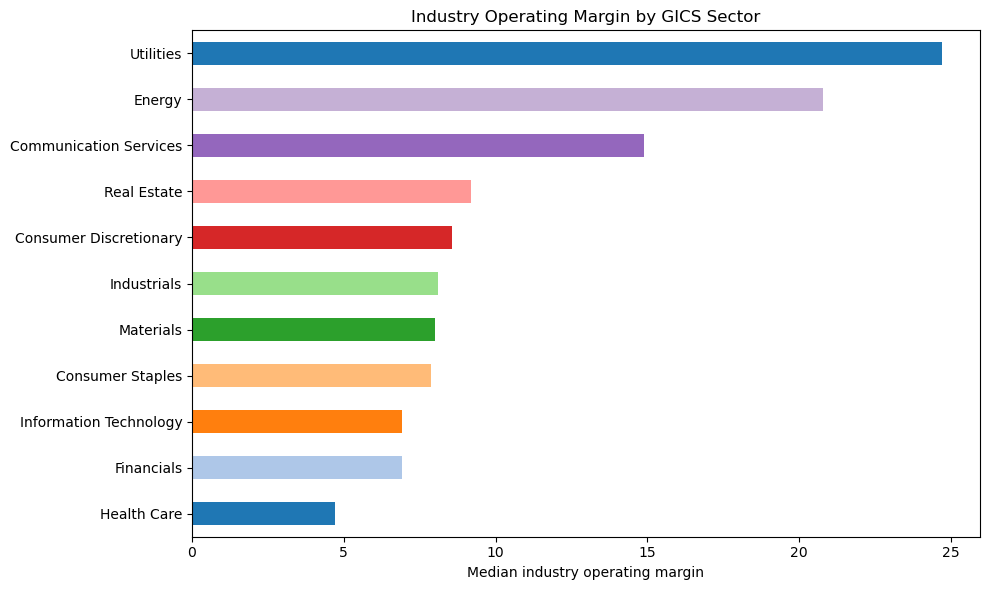

In [212]:
#Plot the industry operating margin by sector
plt.figure(figsize=(10, 6))

(df_1a.groupby('sector')['opm_industry_median']
      .median()
      .sort_values()
      .plot.barh(color=sns.color_palette('tab20', 10)))

plt.xlabel('Median industry operating margin')
plt.ylabel('')
plt.title('Industry Operating Margin by GICS Sector')
plt.tight_layout()
plt.show()

Looking at profitability, the sector divergence story continues: the Operating Margin shows huge divergence between Sectors. The most profitable sectors are also stable ones with Energy, Utilities as well as Communication Services, while Health Care is the least profitable one. This also aligns with the previous discussion in E-P, where Health Care had even negative earnings in the median case.

**Profitability by Lifecycle Stage Dickinson**

Dickinson predicts that there are huge profitability differences between the life cycle stages. In this section I will see if this can be seen in the underlying dataset as well.

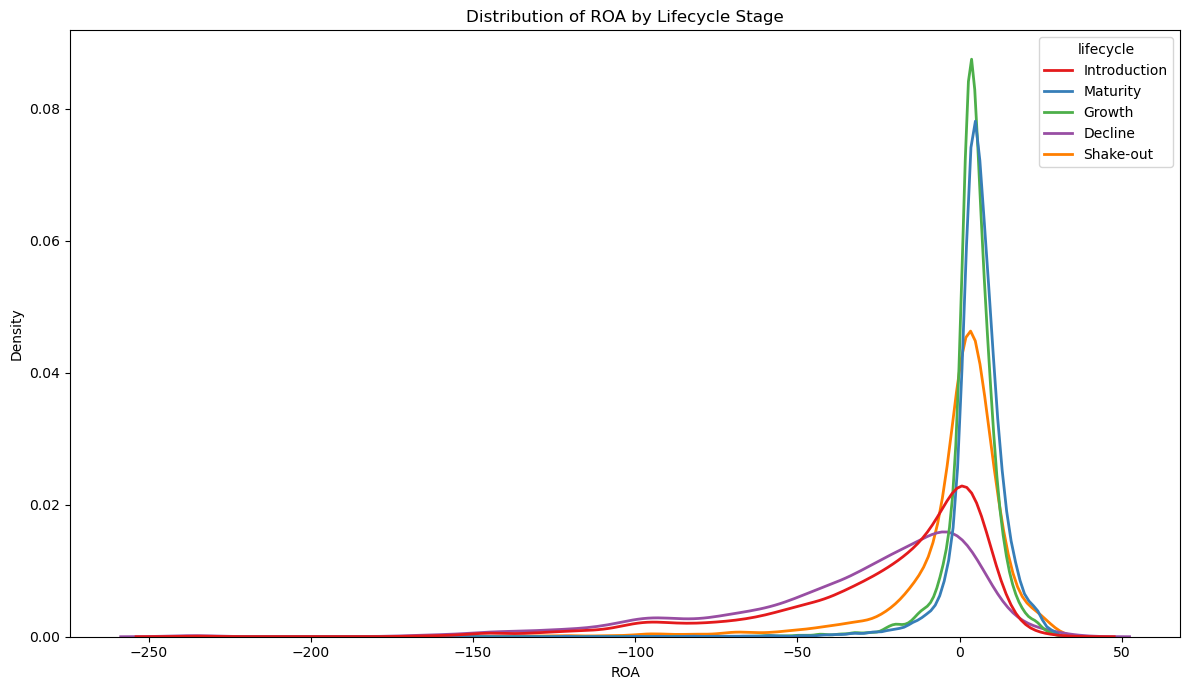

In [213]:
#Plot the Distribution of ROA by Lifecycle Stage
plt.figure(figsize=(12,7))

sns.kdeplot(
    data=df_1a,
    x='ROA',
    hue='lifecycle',
    common_norm=False,
    fill=False,
    linewidth=2
)

plt.xlabel("ROA")
plt.ylabel("Density")
plt.title("Distribution of ROA by Lifecycle Stage")
plt.tight_layout()
plt.show()

To get concrete numbers, a grouped dataframe by Lifecycle Stage is additionally examined.

In [214]:
#Specifcy the order of the lifecycle stages 
order = ['Introduction', 'Growth', 'Maturity', 'Shake-out', 'Decline']

#Groupby Lifecycle Stage and calculate the size, median, mean, standard deviation, and percentage of negative ROA values. Reindex the result to match the specified order 
df_1a.groupby('lifecycle')['ROA'].agg(
n='size',
median='median',
mean='mean',
std='std',
pct_neg=lambda s: (s < 0).mean() * 100,).reindex(order).round(2)

,n,median,mean,std,pct_neg
lifecycle,,,,,
Introduction,7541,-11.84,-23.90,35.43,70.43
Growth,17588,4.14,3.55,9.54,17.72
Maturity,26272,5.61,5.27,9.98,13.25
Shake-out,5104,2.15,-2.39,20.61,37.03
Decline,3615,-21.23,-32.20,38.70,82.24


The results of the distribution and the table are validating Dickinson's findings that there are significantly different profitability levels in the Firm Lifecycle stages, which has a big impact on profitability convergence and therefore for growth rate convergence. Profitability is highest in the Maturity stage, while it is lowest in the Decline stage, with significant differences between these stages. Also in the Introduction and Decline stage more than 70%, 80% respectively of the firms are unprofitable, while in the Maturity stage only 13% of the firms are unprofitable.

### 3.4. Mean-Reversion of Growth

This section deals with the Mean-Reversion in Growth Rates. To justify the forecast horizon used in this thesis it should be shown that after the ending horizon mostly t+10 years no growth differences persist and the terminal growth rate assumption is valid thereafter. To demonstrate this, I am using the past time-series growth to show that the differences between the growth rates of previous slow and fast growing firms, sorted in quintiles, is converging in the target variable over time. For this, first of all, I will group the firms into quintiles based on past growth rates and will look at the Mean Future Growth Rate for the different quintiles over time. Since this is a crucial part of the EDA, I will look at the mean-reversion for all 3 target variables, to see if the results are consistent across the different target variables.

**EBITDA Growth Mean-Reversion**

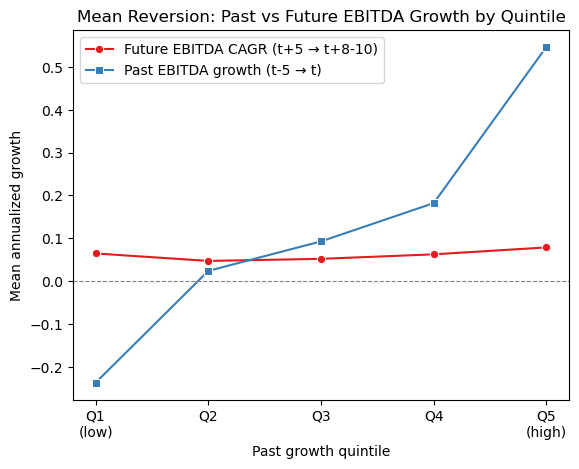

In [215]:
#Copy the dataset and drop rows with missing values in the 'oibdp_growth_lag' and 'ebitda_cagr' 
d = df_1a.dropna(subset=['oibdp_growth_lag', 'ebitda_cagr']).copy()

#Cut the 'oibdp_growth_lag' variable into quintiles and assign the quintile labels to a new column 'past_q'.
d['past_q'] = pd.qcut(d['oibdp_growth_lag'], 5, labels=False, duplicates='drop')

#Calculate the mean of 'ebitda_cagr' and 'oibdp_growth_lag' for each quintile of 'past_q'.
g = d.groupby('past_q')['ebitda_cagr'].mean()        # future
h = d.groupby('past_q')['oibdp_growth_lag'].mean()   # past

#Plot the mean of 'ebitda_cagr' and 'oibdp_growth_lag' for each quintile of 'past_q' 
sns.lineplot(x=g.index, y=g.values, marker='o', label='Future EBITDA CAGR (t+5 → t+8-10)') #Future EBITDA growth (t+5 → t+8-10)
sns.lineplot(x=h.index, y=h.values, marker='s', label='Past EBITDA growth (t-5 → t)') #Past EBITDA growth (t-5 → t)
plt.axhline(0, color='grey', lw=0.8, ls='--')

plt.xticks(range(5), ['Q1\n(low)', 'Q2', 'Q3', 'Q4', 'Q5\n(high)'])
plt.xlabel('Past growth quintile')
plt.ylabel('Mean annualized growth')
plt.title('Mean Reversion: Past vs Future EBITDA Growth by Quintile')
plt.legend()
plt.show()

This is one of the most important insights of the EDA and justifies the forecast horizon of t+5 to t+10, since mean-reversion in the growth rates is clearly visible in this time window. One can see that the slowest growing firms and the fastest growing firms in the past are both converging to similar mean growth rates identified by the moreover flat red line for future growth between the quintiles. This is crucial for the prediction of the target variables, since it shows that the differences between slow and fast growing firms are converging over the ending horizon of t+10 years making the terminal growth assumption thereafter reasonable.

**Sale Growth Mean-Reversion**

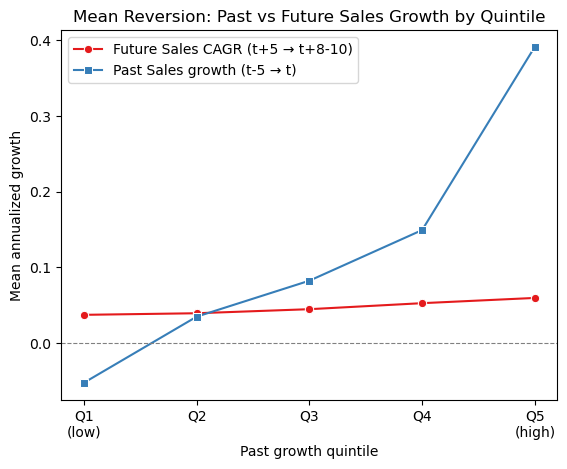

In [216]:
#Copy the dataset and drop rows with missing values in the 'sale_growth_lag' and 'sale_cagr' 
d = df_1a.dropna(subset=['sale_growth_lag', 'sale_cagr']).copy()

#Cut the 'sale_growth_lag' variable into quintiles and assign the quintile labels to a new column 'past_q'.
d['past_q'] = pd.qcut(d['sale_growth_lag'], 5, labels=False, duplicates='drop')

#Calculate the mean of 'sale_cagr' and 'sale_growth_lag' for each quintile of 'past_q'.
g = d.groupby('past_q')['sale_cagr'].mean()        
h = d.groupby('past_q')['sale_growth_lag'].mean()   

#Plot the mean of 'sale_cagr' and 'sale_growth_lag' for each quintile of 'past_q' 
sns.lineplot(x=g.index, y=g.values, marker='o', label='Future Sales CAGR (t+5 → t+8-10)')
sns.lineplot(x=h.index, y=h.values, marker='s', label='Past Sales growth (t-5 → t)')
plt.axhline(0, color='grey', lw=0.8, ls='--')

plt.xticks(range(5), ['Q1\n(low)', 'Q2', 'Q3', 'Q4', 'Q5\n(high)'])
plt.xlabel('Past growth quintile')
plt.ylabel('Mean annualized growth')
plt.title('Mean Reversion: Past vs Future Sales Growth by Quintile')
plt.legend()
plt.show()

**FCFF Growth Mean-Reversion**

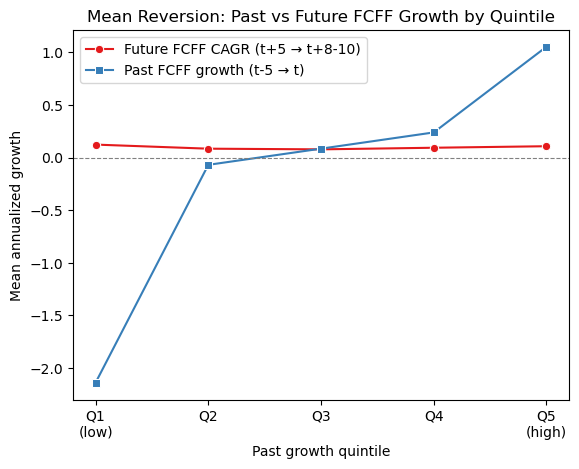

In [217]:
#Copy the dataset and drop rows with missing values in the 'fcff_growth_lag' and 'fcff_cagr' 
d = df_1a.dropna(subset=['fcff_growth_lag', 'fcff_cagr']).copy()

#Cut the 'fcff_growth_lag' variable into quintiles and assign the quintile labels to a new column 'past_q'.
d['past_q'] = pd.qcut(d['fcff_growth_lag'], 5, labels=False, duplicates='drop')

#Calculate the mean of 'fcff_cagr' and 'fcff_growth_lag' for each quintile of 'past_q'.
g = d.groupby('past_q')['fcff_cagr'].mean()        
h = d.groupby('past_q')['fcff_growth_lag'].mean()   

#Plot the mean of 'fcff_cagr' and 'fcff_growth_lag' for each quintile of 'past_q' 
sns.lineplot(x=g.index, y=g.values, marker='o', label='Future FCFF CAGR (t+5 → t+8-10)')
sns.lineplot(x=h.index, y=h.values, marker='s', label='Past FCFF growth (t-5 → t)')
plt.axhline(0, color='grey', lw=0.8, ls='--')

plt.xticks(range(5), ['Q1\n(low)', 'Q2', 'Q3', 'Q4', 'Q5\n(high)'])
plt.xlabel('Past growth quintile')
plt.ylabel('Mean annualized growth')
plt.title('Mean Reversion: Past vs Future FCFF Growth by Quintile')
plt.legend()
plt.show()

Despite level differences, similar mean-reversion patterns can be drawn for the Sale and FCFF target variables. The differences between the quintiles are converging over time, making the terminal growth assumption reasonable for all 3 target variables.

### 3.5. Time-Varying Data Analysis

This section puts a particular emphasis on the time-varying data analysis component. It is highly important to see if the results of the EDA are robust over time due to the aim of this thesis to predict long-term growth rates, which are spanning long periods. Therefore, in a first step I will look at the number of observations that are available for the different target variables over time. This is important to understand from which time periods the later developed Machine Learning Models will be trained on and if there are any time periods with structurally less observations, which could lead to a bias. In a second step, similar to section 3.4., I will look at the mean growth rates over time, to see if there are any structural changes in the growth rates. The third step will be a deeper look at macroeconomic states proxied by the macroeconomic variables to see if there are any structural changes over time that would be relevant for a train-test split decision.

Note: For brevity, this analysis focuses on the EBITDA CAGR. Similar results can be drawn from the other growth rates and LSQ calculations.

**Number of Observations for Target Variable by Year**

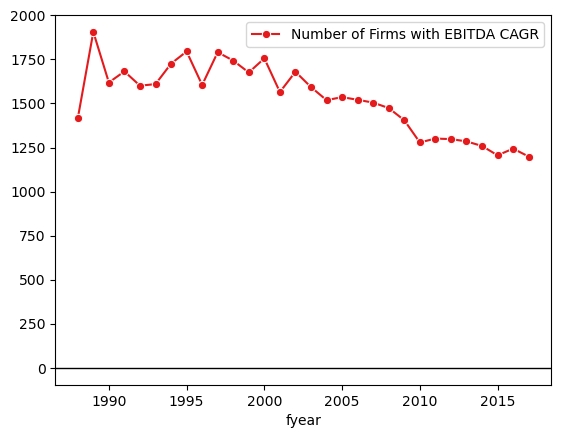

In [218]:
#Create a new column for the dataset that counts the number of firms with a valid EBITDA CAGR grouped by each fiscal year.
d = df_1a.assign(has=df_1a['ebitda_cagr'].notna()).groupby('fyear')['has'].sum()

#Plot the number of firms with a valid EBITDA CAGR over time.
sns.lineplot(x=d.index, y=d.values, marker='o', label='Number of Firms with EBITDA CAGR')
plt.axhline(y=0, color='black', linewidth=1)
plt.legend()

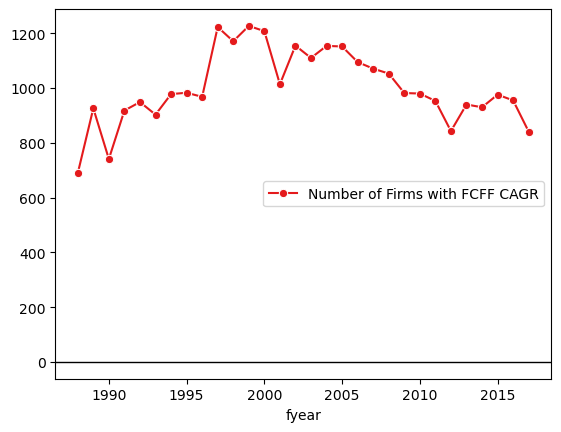

In [219]:
#Create a new column for the dataset that counts the number of firms with a valid FCFF CAGR grouped by each fiscal year.
d = df_1a.assign(has=df_1a['fcff_cagr'].notna()).groupby('fyear')['has'].sum()

#Plot the number of firms with a valid FCFF CAGR over time.
sns.lineplot(x=d.index, y=d.values, marker='o', label='Number of Firms with FCFF CAGR')
plt.axhline(y=0, color='black', linewidth=1)
plt.legend()

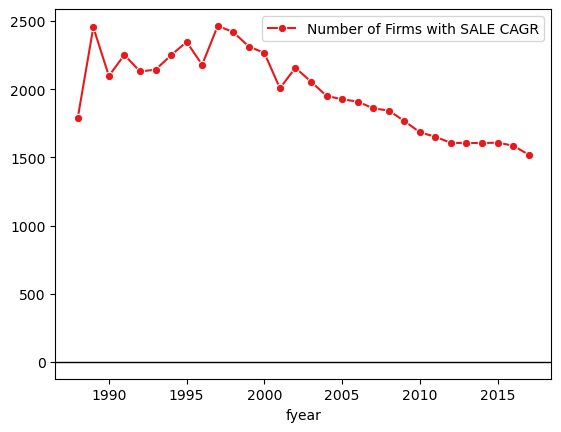

In [220]:
#Create a new column for the dataset that counts the number of firms with a valid Sales CAGR grouped by each fiscal year.
d = df_1a.assign(has=df_1a['sale_cagr'].notna()).groupby('fyear')['has'].sum()


#Plot the number of firms with a valid Sales CAGR over time.
sns.lineplot(x=d.index, y=d.values, marker='o', label='Number of Firms with SALE CAGR')
plt.axhline(y=0, color='black', linewidth=1)
plt.legend()

The dataset shows a slight but significant decline in the years beginning from approximately 2000 for all 3 target variables. While this might be a surprising finding since one would expect that the number of observations would increase over time due to better data coverage, it is actually well documented in the literature under 'Listing Gap', which means that the number of listed firms is declining over time, which can potentially explain the decline in the number of observations for the target variables over time. To see if the 'Listing Gap' is also visible in the broader dataset without the target variable constraint, I will also look at the number of unique firms in the former dataset over time.

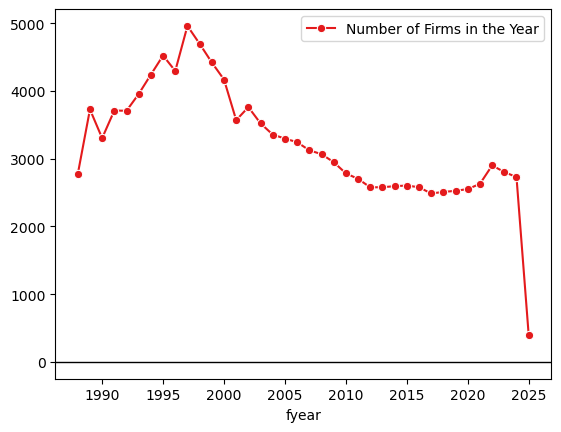

In [221]:
#Create a new column for the dataset without target variable constraint that counts the number of firms grouped by each fiscal year.
d = df_1.groupby('fyear')['gvkey'].nunique()

#Plot the number of firms over time
sns.lineplot(x=d.index, y=d.values, marker='o', label='Number of Firms in the Year')
plt.axhline(y=0, color='black', linewidth=1)
plt.legend()

The results show that, as in the dataset with a target variable, the number of unique firms is declining over time, which confirms the 'Listing Gap' hypothesis. This is an important finding for the later modeling section, since it shows that the models will be trained on a declining number of observations over time, which could lead to a bias because of the significant number of observations in the earlier years compared to the later years. In the next section, the mean growth rates over time are examined, to see if there are any structural time varying changes in the growth rates, which would interline with the time-varying number of observations and could lead to a bias.

Note: There are not many companies in 2025, since they have not reported their financials yet (not a structural but more an expected result).

**Mean Evolution of the Target Growth Variables over Time**

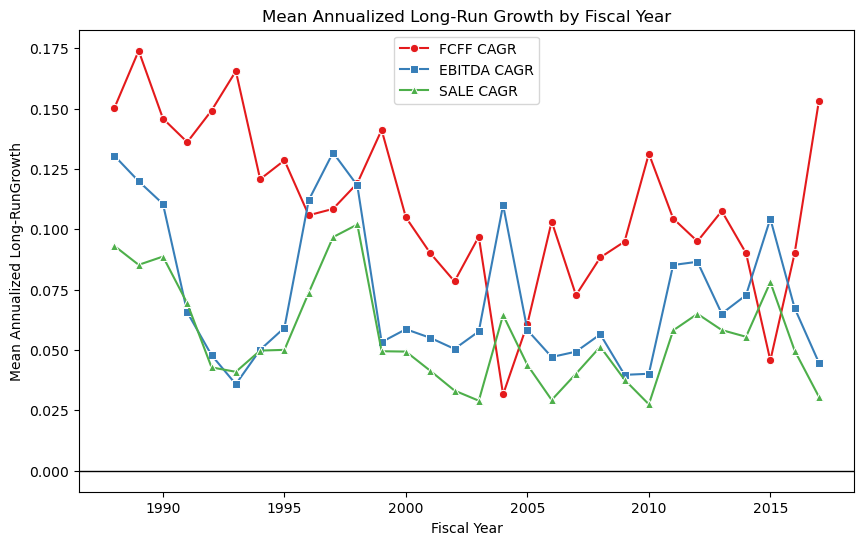

In [222]:
#Calculate the mean of the target variables (FCFF CAGR, EBITDA CAGR, and Sales CAGR) for each fiscal year.
d = df_1a.groupby('fyear')['fcff_cagr'].mean()
e = df_1a.groupby('fyear')['ebitda_cagr'].mean()
f = df_1a.groupby('fyear')['sale_cagr'].mean()

fig, ax = plt.subplots(figsize=(10, 6))

#Plot the mean of the target variables  for each fiscal year.
sns.lineplot(x=d.index, y=d.values, marker='o', label='FCFF CAGR')
sns.lineplot(x=e.index, y=e.values, marker='s', label='EBITDA CAGR')
sns.lineplot(x=f.index, y=f.values, marker='^', label='SALE CAGR')
plt.axhline(y=0, color='black', linewidth=1)

ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Mean Annualized Long-RunGrowth')
plt.title('Mean Annualized Long-Run Growth by Fiscal Year')
plt.legend()
plt.show()

Fortunately, although the mean growth rates of EBITDA and Sales are pretty volatile over time, they do not show any structural trends over time. However, the FCFF was decreasing structurally until aroound 2000, but seems to be stable from a structural trend perspective since then. Having no structural trends is an important finding that mitigates the declining number of more recent observations, because the mean growth rates are not changing over time.

**Macroeconomic States**

The goal of this section is to look if there were any structural changes in macroeconomic states that could have an impact on the train-test split decisions of the notebook. For instance, if the models are only trained in low interest environments, they might not be able to predict growth rates in high interest rate environments, which could induce a potential bias. Therefore, I will look at the macroeconomic variables to see if there are any structural changes in the macroeconomic states over time.

Text(0, 0.5, 'Spread')

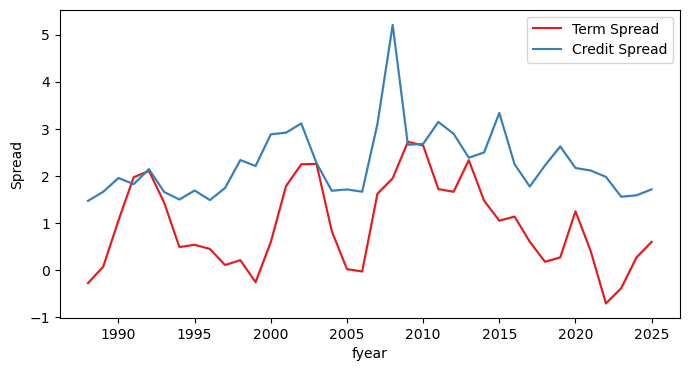

In [223]:
#Plot the distribution of the term spread and credit spread over time.
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=df_1, x='fyear', y='term_spread', label='Term Spread', ax=ax)
sns.lineplot(data=df_1, x='fyear', y='credit_spread', label='Credit Spread', ax=ax)
ax.set_ylabel('Spread')

In terms of spreads there are no structural trends over time, although there are definitely crisis periods with higher spreads, which is in line with economic theory. One has to be aware that the high spreads after the financial crisis in 2008, which have not been seen before, could substantially affect the later developed model performance if the test cut off is before 2008.

Text(0, 0.5, 'Percentage%')

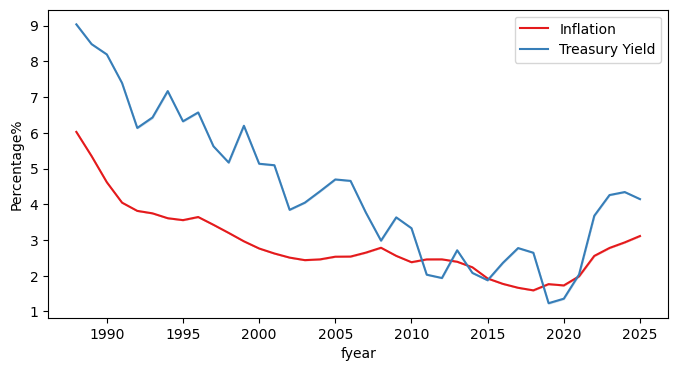

In [224]:
#Plot the distribution of the Inflation and Treasury Yield over time.

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=df_1, x='fyear', y='inflation_rate_10y', label='Inflation', ax=ax)
sns.lineplot(data=df_1, x='fyear', y='treasury_yield', label='Treasury Yield', ax=ax)
ax.set_ylabel('Percentage%')

Regarding interest rates and inflation, the ML models will be trained & tested (target variable available until 2017) on a declining trend in both figures. The real problem is a potential model bias beginning in 2020, since the interest rates and inflation are structurally rising and this can not be trained and tested because the target variable is not available for these years. An interesting point for future research when the dataset expands is to look if the model results also hold in a structural rising interest rate and inflation environment.

<Axes: xlabel='fyear', ylabel='gdp_growth_rate_10y'>

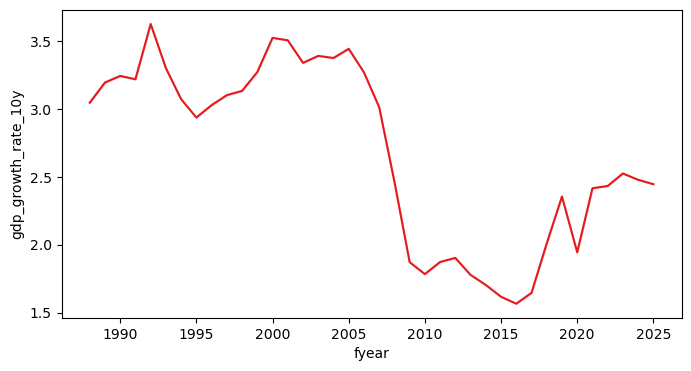

In [225]:
#Plot rolling 10-year GDP growth rate over time.
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=df_1, x='fyear', y='gdp_growth_rate_10y')

Rolling GDP growth experiences similar structural breaks in 2008 as the credit spread events. Models trained before the financial crisis will significantly see higher GDP growth numbers in the train set than in the test set.

---

## **4. Multivariate Data Analysis**

This section focuses on Multivariate Data Analysis. Specifically, the Mean Reversion effects of the previous chapters are tested depending on Time, Lifecycle Stage and Profitability (Section 4.1.). Next, since profitability analysis is central to the EDA, I explore the target Variable by Sector for above-average vs below-average performers in terms of profitability margins. Further, Section 4.3. deals with Principal Component Analysis (PCA) to see if the dimensionality of the dataset could be reduced, to see if the justification of the multidimensional dataset is valid or if high multicollinearity is present in the dataset.

### 4.1. Mean-Reversion Depending on Time, Lifecycle Stage and Profitability

**Time Varying Mean Reversion**

First I will look at the mean-reversion of the growth rates but depending on time. The procedure is similar to the one in Section 3.4. The dataset is grouped based on past growth rates into quintiles. For these quintiles the mean future growth rates are elaborated and the past and future growths for the quintiles are plotted. The only difference is that the dataset is filtered into 3 time periods, before 2000, between 2000 and 2010 and after 2010, to see if the mean-reversion effects are robust over time.

Note: I use Sales CAGR here (because results are visually easier to read than for EBITDA), however the results also hold for the other proxies

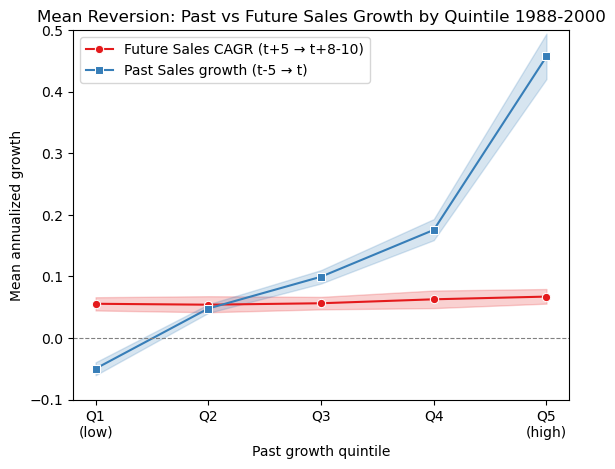

In [226]:
#Copy the dataset and drop rows with missing values in the 'sale_growth_lag' and 'sale_cagr' 
d = df_1a.dropna(subset=['sale_growth_lag', 'sale_cagr']).copy()

#Cut the 'sal_growth_lag' variable into quintiles and assign the quintile labels to a new column 'past_q'.
d['past_q'] = d.groupby('fyear')['sale_growth_lag'].transform(lambda s: pd.qcut(s, 5, labels=False, duplicates='drop'))

#Calculate the mean of 'sale_cagr' and 'sale_growth_lag' for each quintile of 'past_q'.
g = d.groupby(['fyear', 'past_q'])['sale_cagr'].mean()        
h = d.groupby(['fyear', 'past_q'])['sale_growth_lag'].mean()   

#Filter the data to only include fiscal years up to 2000
g = g[g.index.get_level_values('fyear') <= 2000]
h = h[h.index.get_level_values('fyear') <= 2000]

#Set index back to past_q for plotting
g = g.reset_index(level=0, drop=True)
h = h.reset_index(level=0, drop=True)

#Plot the mean of 'sale_cagr' and 'sale_growth_lag' for each quintile of 'past_q' 
sns.lineplot(x=g.index, y=g.values, marker='o', label='Future Sales CAGR (t+5 → t+8-10)')
sns.lineplot(x=h.index, y=h.values, marker='s', label='Past Sales growth (t-5 → t)')
plt.axhline(0, color='grey', lw=0.8, ls='--')
plt.ylim(-0.10, 0.50)

plt.xticks(range(5), ['Q1\n(low)', 'Q2', 'Q3', 'Q4', 'Q5\n(high)'])
plt.xlabel('Past growth quintile')
plt.ylabel('Mean annualized growth')
plt.title('Mean Reversion: Past vs Future Sales Growth by Quintile 1988-2000')
plt.legend()
plt.show()

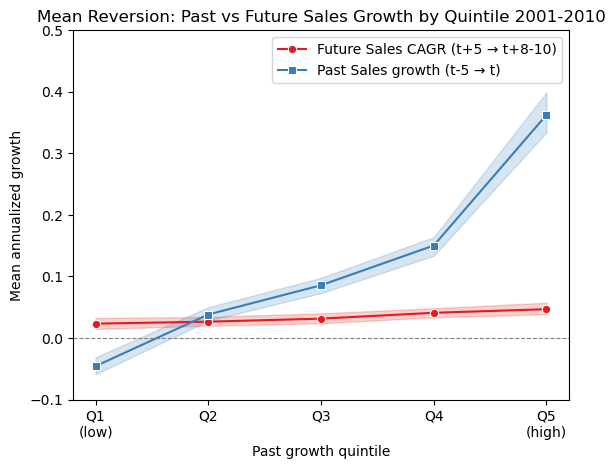

In [227]:
#Copy the dataset and drop rows with missing values in the 'sale_growth_lag' and 'sale_cagr' 
d = df_1a.dropna(subset=['sale_growth_lag', 'sale_cagr']).copy()

#Cut the 'sal_growth_lag' variable into quintiles and assign the quintile labels to a new column 'past_q'.
d['past_q'] = d.groupby('fyear')['sale_growth_lag'].transform(lambda s: pd.qcut(s, 5, labels=False, duplicates='drop'))

#Calculate the mean of 'sale_cagr' and 'sale_growth_lag' for each quintile of 'past_q'.
g = d.groupby(['fyear', 'past_q'])['sale_cagr'].mean()       
h = d.groupby(['fyear', 'past_q'])['sale_growth_lag'].mean()   

#Filter the data to only include fiscal years between 2000 and 2010
g = g[(g.index.get_level_values('fyear') > 2000) & (g.index.get_level_values('fyear') <= 2010)]
h = h[(h.index.get_level_values('fyear') > 2000) & (h.index.get_level_values('fyear') <= 2010)]

#Set index back to past_q for plotting
g = g.reset_index(level=0, drop=True)
h = h.reset_index(level=0, drop=True)


#Plot the mean of 'sale_cagr' and 'sale_growth_lag' for each quintile of 'past_q' 
sns.lineplot(x=g.index, y=g.values, marker='o', label='Future Sales CAGR (t+5 → t+8-10)')
sns.lineplot(x=h.index, y=h.values, marker='s', label='Past Sales growth (t-5 → t)')
plt.axhline(0, color='grey', lw=0.8, ls='--')
plt.ylim(-0.10, 0.50)

plt.xticks(range(5), ['Q1\n(low)', 'Q2', 'Q3', 'Q4', 'Q5\n(high)'])
plt.xlabel('Past growth quintile')
plt.ylabel('Mean annualized growth')
plt.title('Mean Reversion: Past vs Future Sales Growth by Quintile 2001-2010')
plt.legend()
plt.show()

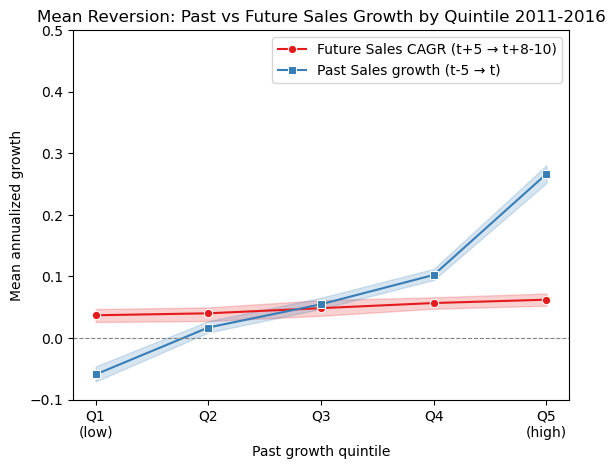

In [228]:
#Copy the dataset and drop rows with missing values in the 'sale_growth_lag' and 'sale_cagr' 
d = df_1a.dropna(subset=['sale_growth_lag', 'sale_cagr']).copy()

#Cut the 'sal_growth_lag' variable into quintiles and assign the quintile labels to a new column 'past_q'.
d['past_q'] = d.groupby('fyear')['sale_growth_lag'].transform(lambda s: pd.qcut(s, 5, labels=False, duplicates='drop'))

#Calculate the mean of 'sale_cagr' and 'sale_growth_lag' for each quintile of 'past_q'.
g = d.groupby(['fyear', 'past_q'])['sale_cagr'].mean()        
h = d.groupby(['fyear', 'past_q'])['sale_growth_lag'].mean()   

#Filter the data to only include fiscal years from 2011 to 2017
g = g[(g.index.get_level_values('fyear') > 2010)]
h = h[(h.index.get_level_values('fyear') > 2010)]

#Set index back to past_q for plotting
g = g.reset_index(level=0, drop=True)
h = h.reset_index(level=0, drop=True)


#Plot the mean of 'sale_cagr' and 'sale_growth_lag' for each quintile of 'past_q' 
sns.lineplot(x=g.index, y=g.values, marker='o', label='Future Sales CAGR (t+5 → t+8-10)')
sns.lineplot(x=h.index, y=h.values, marker='s', label='Past Sales growth (t-5 → t)')
plt.axhline(0, color='grey', lw=0.8, ls='--')
plt.ylim(-0.10, 0.50)

plt.xticks(range(5), ['Q1\n(low)', 'Q2', 'Q3', 'Q4', 'Q5\n(high)'])
plt.xlabel('Past growth quintile')
plt.ylabel('Mean annualized growth')
plt.title('Mean Reversion: Past vs Future Sales Growth by Quintile 2011-2016')
plt.legend()
plt.show()

Even though there are level differences in the mean-reversion, e.g. the mean is lower for all quintiles between 2000-2010 for instance, there seem to be no structural differences in the mean reversion between the different time periods. These results help to justify that mean-reversion is a time independent phenomenon, which is a crucial assumption for the thesis, since the Machine Learning Models will be trained on a long-horizon of past data.

**Life Cycle x Mean Reversion**

In the next section I will look at the mean reversion of the growth rates by lifecycle stage. Dickinson predicts that mean reversion differs between the different lifecycle stages. The procedure is similar to the time-varying mean-reversion analysis, but instead of grouping the dataset per time period, I will group the dataset by lifecycle stage.

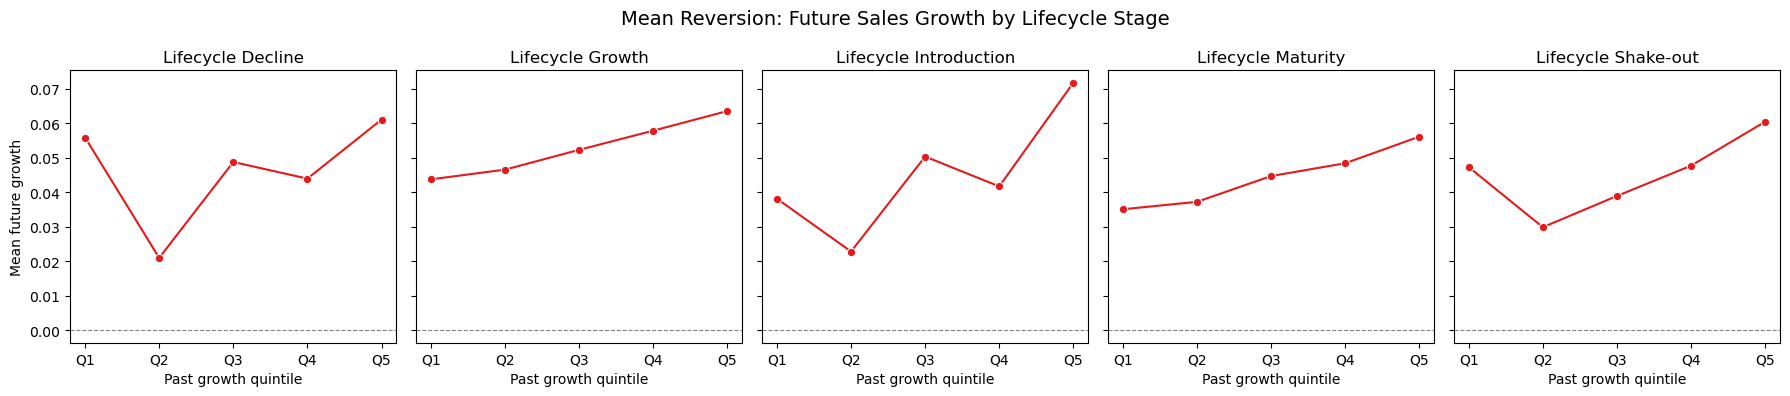

In [229]:
# Growth reversion within Lifecycle stages quintiles

#Copy the dataset and drop rows with missing values in the 'sale_growth_lag' and 'sale_cagr'
d = df_1a.dropna(subset=['sale_growth_lag', 'sale_cagr']).copy()

#Add the new column 'past_q' to the dataset that contains the quintile labels of 'sale_growth_lag' grouped by 'lifecycle'.
d['past_q'] = (d.groupby('lifecycle')['sale_growth_lag'].transform(lambda s: pd.qcut(s, 5, labels=False, duplicates='drop')))

#Multi Index Series with the mean of 'sale_cagr' grouped by 'lifecycle' and 'past_q'.
g = d.groupby(['lifecycle', 'past_q'])['sale_cagr'].mean()


fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

#For each lifecycle stage, plot the mean of 'sale_cagr' (y-axis) against the quintiles of 'past growth quintiles' (x-axis) in a separate subplot.

#Iterate over the unique lifecycle stages and the corresponding axes to plot the mean of 'sale_cagr' for each lifecycle stage.
for lifecycle, ax in zip(sorted(d['lifecycle'].unique()), axes):

    #Helps to get rid of the multi-index and select only the data for the current lifecycle stage.
    y = g.xs(lifecycle, level='lifecycle')

#Plot the mean of 'sale_cagr' for the current lifecycle stage
    sns.lineplot(x=y.index, y=y.values, marker='o', ax=ax)

    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_xticks(range(5), ['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    ax.set_xlabel('Past growth quintile')
    ax.set_title(f'Lifecycle {lifecycle}')

axes[0].set_ylabel('Mean future growth')

fig.suptitle(
    'Mean Reversion: Future Sales Growth by Lifecycle Stage',
    fontsize=14
)

plt.tight_layout()
plt.show()

Mean Reversion is not that obvious when grouped in different lifecycle stages. While Growth and Maturity show more mean reversion tendencies (with some upward tendencies for the Growth Stages), the other stages have zig-zag patterns with no clear mean-reversion tendencies for the stages.

**Mean Reversion by Profitability Quintiles**

Similar steps are followed in the mean reversion for Profitability quintiles. The dataset is grouped by profitability quintiles and the mean future growth rates are elaborated for the different quintiles.

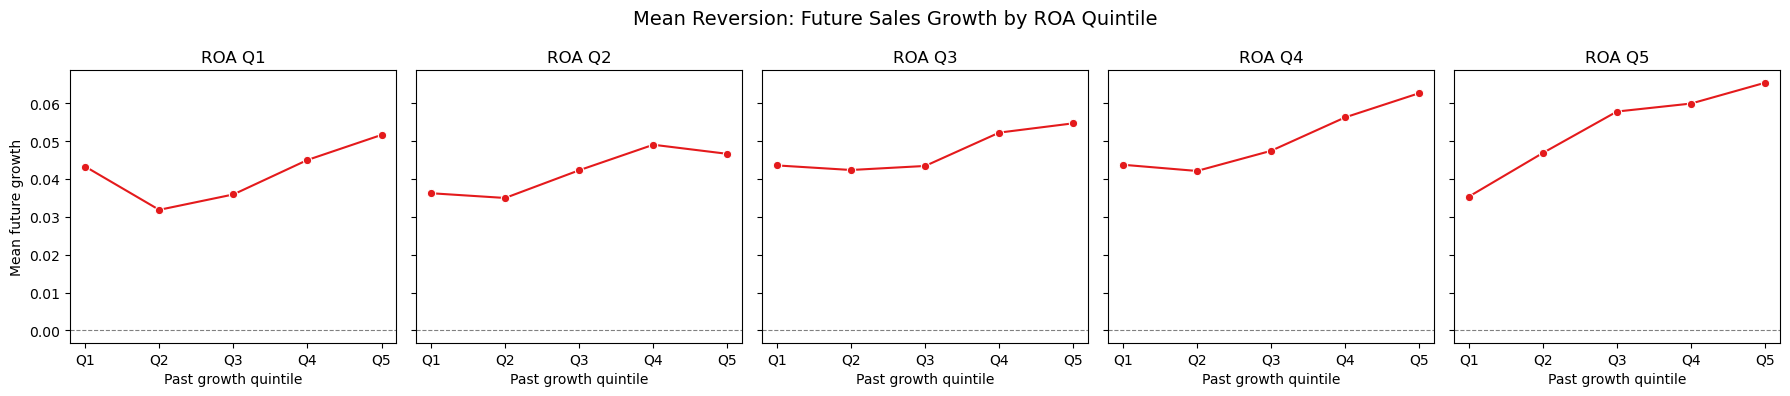

In [230]:
#Growth reversion within ROA quintiles
d = df_1a.dropna(subset=['ROA','sale_growth_lag','sale_cagr']).copy()
d['roa_q']  = d.groupby('fyear')['ROA'].transform(lambda s: pd.qcut(s, 5, labels=False, duplicates='drop'))
d['past_q'] = d.groupby(['fyear','roa_q'])['sale_growth_lag'].transform(lambda s: pd.qcut(s, 5, labels=False, duplicates='drop'))

g = d.groupby(['roa_q','past_q'])['sale_cagr'].mean()

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for q, ax in enumerate(axes):
    sns.lineplot(x=g.loc[q].index, y=g.loc[q].values, marker='o', ax=ax)
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_xticks(range(5), ['Q1','Q2','Q3','Q4','Q5'])
    ax.set_xlabel('Past growth quintile')
    ax.set_title(f'ROA Q{q+1}')
axes[0].set_ylabel('Mean future growth')

fig.suptitle('Mean Reversion: Future Sales Growth by ROA Quintile', fontsize=14)
plt.tight_layout()
plt.show()

One can see that the line is not totally flat in terms of mean-reversion of growth when split into different ROA quintiles. Especially the ROA Q4 and Q5 quintiles have steep upward lines, which indicates that the mean reversion is lower for the higher ROA quintiles. The lowest profitable quintile is experiencing U-shaped mean reversion, while the Q2 and Q3 profitable quintiles are behaving more modestly.

### 4.2. Target Variable by Sector for above-average vs below-average profitability margin

Because profitability is playing such a crucial role in this EDA, the following section will look at a multivariate analysis of the Distributions of the Target Growth Rate (EBITDA CAGR) by Outperformers and Underperformers in terms of profitability (ROA) by Sector.

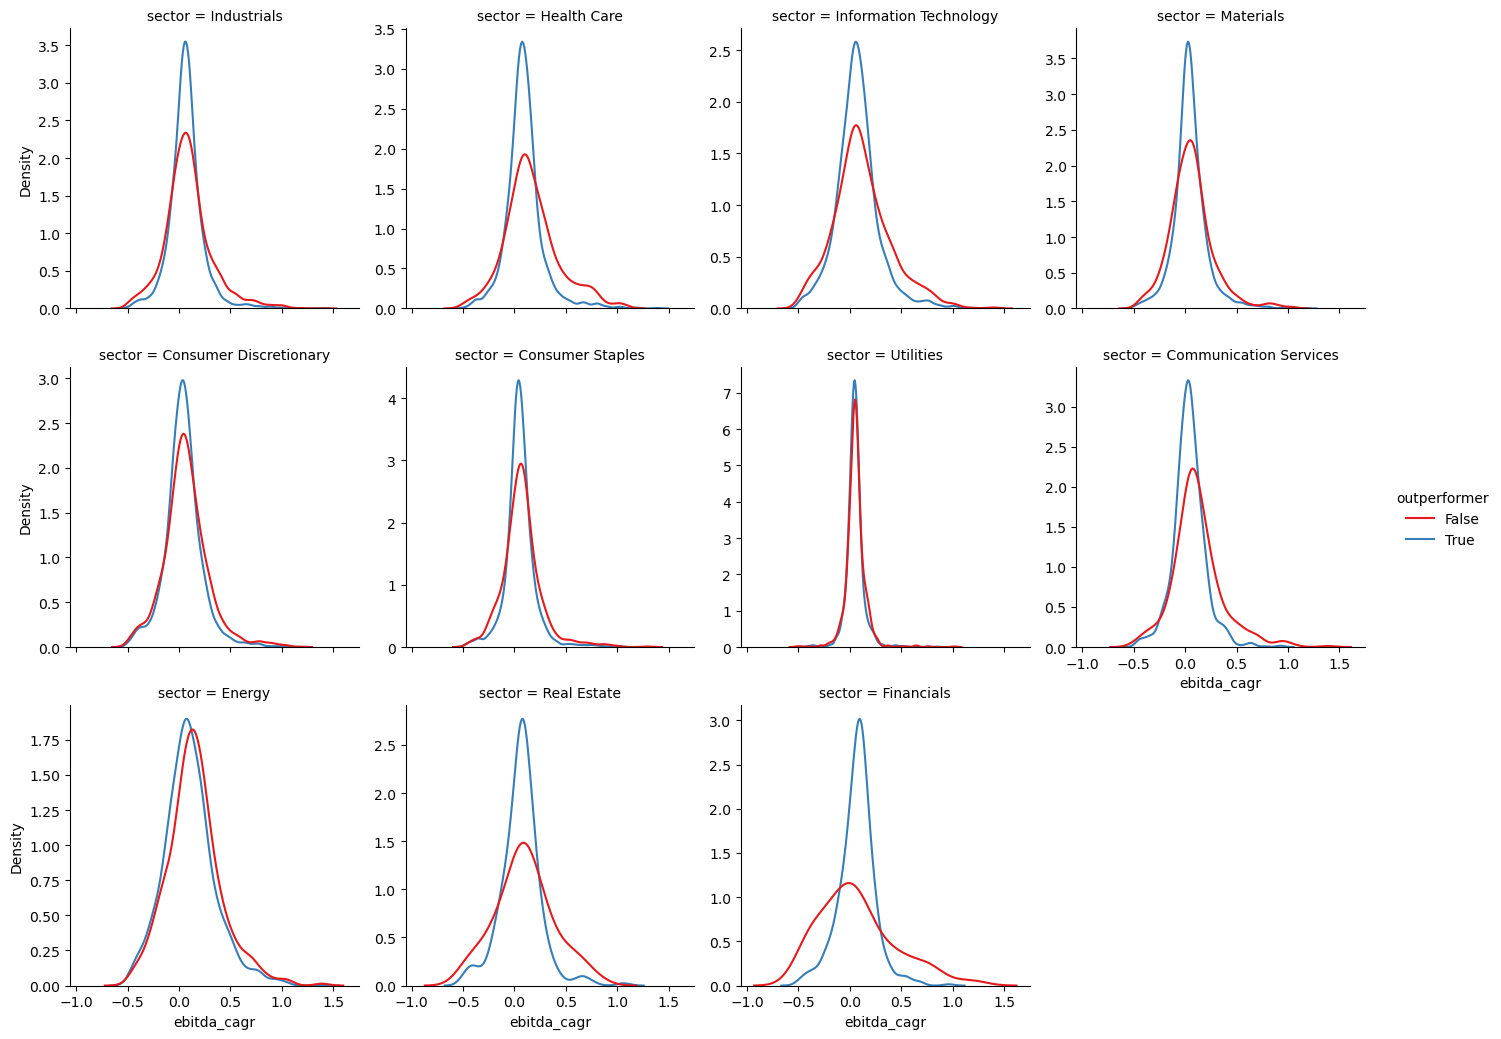

In [231]:
#If more proftable than the industry median, then the firm assign Yes. If less profitable than the industry median, then assign no.
df_1a['outperformer'] = df_1a['op_margin'] > df_1a['opm_industry_median']
df_1a['outperformer'].map({True: 'Yes', False: 'No'})

sns.displot(data=df_1a, x="ebitda_cagr", col="sector", hue="outperformer", kind="kde", col_wrap=4, height=3.5, facet_kws={'sharex': True, 'sharey': False}, common_norm=False)

As noted before, EBITDA CAGR differences are visible between sectors. This plot looks at an additional within sector component, namely the profitability of the firms within the sector. Firms that are more profitable than the industry median tend to have a tighter distribution across sectors compared to underperformers, however the central tendency of the distribution is similar for both groups.

### 4.3. Principal Component Analysis (PCA)

Since the dataset is highly dimensional, I will use a PCA approach to look at dimensionality reduction of the dataset, to see how many uncorrelated dimensions are in the dataset. This is important to see if the dataset can be reduced to a lower dimensional space.

In [232]:
#Look at the Shape of the Orginal dataset: 

df_1a.shape

(60120, 58)

In [233]:
features = ['mom_12_1','beta','idio_vol','mkvalt_adj','fcff','credit_spread','term_spread',
      'treasury_yield','inflation_rate_10y','gdp_growth_rate_10y','div_yield','B-M','E-P','S-P',
      'ROA','ROE','op_margin','capex_int','payout_ratio','D-A','D-EBITDA',
      'fcff_growth_lag','oibdp_growth_lag','sale_growth_lag','sustain_g','hhi',
      'roa_industry_median','roe_industry_median','opm_industry_median','type_durable']


print(f'Features in the dataset w/o analyst coverage: {len(features)}')

#Only use the defined features
X  = df_1a[features].dropna() 

#PCA needs standardized data, so we standardize the features before applying PCA.
Xs = StandardScaler().fit_transform(X)  

#Fit PCA to the standardized data and calculate the cumulative explained variance ratio.
pca = PCA().fit(Xs)

#Calculate the cumulative explained variance ratio to determine how many components are needed to explain 90% of the variance in the data.                       
cum = np.cumsum(pca.explained_variance_ratio_)
print(f'Number of components to explain 90% of variance: {np.argmax(cum >= 0.9) + 1}')

Features in the dataset w/o analyst coverage: 30
Number of components to explain 90% of variance: 19


 19 components are needed to explain 90% of the variance in the dataset, which justifies the highly dimensional nature of the dataset. This means that most of the features in the feature set are carrying a lot of distinct information. Note that this does not prove that all of the features are necessarily good predictors for the target variables.

---

## **5. EDA Storage**

In [234]:
#7. Microcap control dataset

#Microcap control like in Replicating anomalies: Lowest 20th percentile of NYSe stocks  
#Filter to get NYSE stocks only for NYSE size:

#Has to be wirtten nyse_stocks with compustat / crsp data directly

#nyse_stocks = final_dataset_2[final_dataset_2['PrimaryExch'] == 'N']
#print(f" 20th percentile of NYSE stocks have a market capitalization of: {np.percentile(nyse_stocks['mkvalt_adj'], 20)}")

#Drop all of these from the current dataset to get rid of microcap stocks:
#final_dataset_microadj = final_dataset_2[final_dataset_2['mkvalt_adj'] > np.percentile(nyse_stocks['mkvalt_adj'], 20)]
#print(f' The length of the microcap-adjusted dataset is: {len(final_dataset_microadj)}')

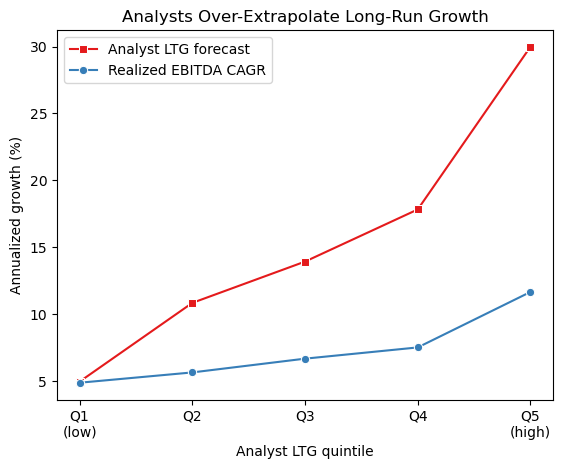

In [235]:
#Not usable in this form because different time horizons 

a = df_a.dropna(subset=['ltg_mean', 'ebitda_cagr']).copy()
a['ltg_q'] = pd.qcut(a['ltg_mean'], 5, labels=False, duplicates='drop')

rev = a.groupby('ltg_q').agg(
    n        = ('ebitda_cagr', 'size'),
    ltg_fcst = ('ltg_mean', 'mean'),                    # %
    realized = ('ebitda_cagr', lambda s: s.mean() * 100),  # -> %
).round(2)
rev['over_extrapolation'] = (rev['ltg_fcst'] - rev['realized']).round(2)
rev


sns.lineplot(x=rev.index, y=rev['ltg_fcst'], marker='s', label='Analyst LTG forecast')
sns.lineplot(x=rev.index, y=rev['realized'], marker='o', label='Realized EBITDA CAGR')
plt.xticks(range(5), ['Q1\n(low)','Q2','Q3','Q4','Q5\n(high)'])
plt.xlabel('Analyst LTG quintile'); plt.ylabel('Annualized growth (%)')
plt.title('Analysts Over-Extrapolate Long-Run Growth'); plt.legend(); plt.show()

### 5.1. Outlier Handling

I will write a custom function for outlier reduction. Outlier classification was inspired by the renowned Tukey Rule. The Tukey Rule identifies outliers as any data points that fall below Q1−1.5×IQR or above Q3+1.5×IQR, where IQR=Q3−Q1 represents the interquartile range, covering the middle 50% of the data. More formally: Outliers = {x ∣ x < Q1−1.5×IQR or x > Q3+1.5×IQR} (Tukey, 1977). In the customized function a more conservative threshold of 2×IQR is applied, because the data suffers from quite a high data dispersion. One must beware that this is a potential limitation of the preprocessing section.

Note the function is inspired by the following Stack Overflow source: https://stackoverflow.com/questions/76441643/how-to-flag-tukey-outliers-using-python-pandas-groupby

Before looking at the remaining outliers, the 1st and 99th percentile of the data are winsorized.

In [236]:
def winsorize_1q(data):
    """
    Winsorizes the input data at the 1st and 99th percentiles.
    
    Parameters:
        data (pd.Series): The input data to be winsorized.
    """
    #Copy orginal data to avoid modifying it directly
    data = data.copy()

    for col in data.select_dtypes(include='number').columns:
        lower = data[col].quantile(0.01)
        upper = data[col].quantile(0.99)
        data[col] = data[col].clip(lower, upper)
    return data


    

# Function to identify outliers in a given series 'x' based on IQR (Interquartile Range)
def get_outlier(x,threshold=2):
    # Calculate the 25th and 75th percentiles (Q1 and Q3) of the data
    q1=x.quantile(.25)
    q3=x.quantile(.75)

    # Calculate the Interquartile Range (IQR)
    IQR=q3-q1

    # Calculate the lower and upper limits for outlier detection
    lowerlimit = q1 - threshold*IQR
    upperlimit = q3 + threshold*IQR

    # Return the number of outliers, those that are outside the lower and upper limits
    return sum((x<lowerlimit) | (x>upperlimit))

#Only look at numerical columns: 
def sort_outliers(data):
    
    #Empty Outlier List
    outlier_list = []
     
    #Fill the List with Percentage of Outliers and sort accordningly
    for col in data.select_dtypes(include='number').columns:
        outlier_list.append((col, round(get_outlier(data[col]) / len(data) * 100, 2)))
        outlier_list.sort(key=lambda x: x[1], reverse=True)
    
    #Print the outliers
    for name, col in outlier_list:
        print(f'Total percentage of outliers in {name}: {col} % ')

sort_outliers(df_1[(df_1['ebitda_cagr'].notna()) | (df_1['sale_cagr'].notna()) | (df_1['fcff_cagr'].notna())])


Total percentage of outliers in opm_industry_median: 18.36 % 
Total percentage of outliers in sale_lsq_nobs: 17.15 % 
Total percentage of outliers in sale_cagr_end: 16.39 % 
Total percentage of outliers in fcff: 14.66 % 
Total percentage of outliers in ROE: 12.66 % 
Total percentage of outliers in sustain_g: 12.58 % 
Total percentage of outliers in mkvalt_adj: 12.56 % 
Total percentage of outliers in gvkey: 12.15 % 
Total percentage of outliers in ebitda_cagr_end: 11.43 % 
Total percentage of outliers in E-P: 11.43 % 
Total percentage of outliers in fcff_growth_lag: 11.32 % 
Total percentage of outliers in ROA: 11.3 % 
Total percentage of outliers in op_margin: 10.21 % 
Total percentage of outliers in capex_int: 9.56 % 
Total percentage of outliers in roa_industry_median: 9.54 % 
Total percentage of outliers in payout_ratio: 7.32 % 
Total percentage of outliers in fcff_cagr_end: 7.18 % 
Total percentage of outliers in S-P: 6.99 % 
Total percentage of outliers in hhi: 6.39 % 
Total perc